# cluster specific TF-gene activaltion
#### cluster can be cell type, niche, spatial cluster etc

1. Link peaks to marker genes for clusters and to genes in gene set
    - annotate as proximal: 100-2000bp upstream TSS 
    - annotate as distal: +/- 150kbp TSS (and not proximal)
2. Identify relevant peaks for specific cluster: differs from BA
    - test for cluster: overaccessible compared to background clusters?
3. Identify TFs for which motifs are enriched in these peaks 
    - continue with 2 analysis paths: 
        - for single clusters
        - for all clusters
4. Score local footprints
    - mean(valley) - mean(flanks)
    - standard diviation in flanks/ total number of sites with Tn5 insertions in flanks



In [ ]:
library(parallel)
library(GenomicFeatures)
set.seed(1234)
library(repr)
library(motifmatchr)
library(fastmatch)
library(qlcMatrix)

library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(AnnotationFilter)

library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)
library(Matrix)
library(zoo)
library(tidyr)

source("../multiome_methods/function_calls.r")
source("../multiome_methods/peak_gene_relations.r")
source("../multiome_methods/binding_site_identification.r")
source("../multiome_methods/TF_activity.r")
source("../multiome_methods/signac_utils.r")

library(dplyr)

library(ggplot2)
library(hexbin)
library(RColorBrewer)
library(cowplot)
library(gridExtra)
library(ggExtra)

library(pheatmap)
library(purrr)
library(data.table)
library(Rsamtools)
library(stringi)


### heart data: AVN
The **atrioventricular (AV) node** is the electrical “gate” between the atria and ventricles. Its main jobs are to **delay conduction** long enough for the atria to empty into the ventricles before ventricular contraction, **filter very rapid atrial impulses** so the ventricles are not driven at dangerously high rates, and serve as a **backup pacemaker** if the sinus node fails. Those functions come from its characteristically **slow conduction**, **long refractory period**, and some **automaticity**. ([ResearchGate][1])

A very meaningful gene-regulatory pathway in AV nodal tissue is the **BMP2 → TBX2/TBX3 AV-canal/AV-node program**. During development, **BMP2** in the atrioventricular canal activates **TBX2** and **TBX3**; together with factors such as **MSX1/MSX2** and interaction with **NKX2-5**, this program **suppresses the ordinary working-myocardium gene program** and preserves the nodal phenotype. In practical terms, it represses chamber/fast-conduction genes such as **NPPA (ANF)**, **GJA5 (Cx40)**, and **GJA1 (Cx43)**, which helps maintain the AV node’s **slow-conducting, nodal identity** rather than letting it become ordinary atrial or ventricular muscle. ([PMC][2])

-> the AV node exists to **time and protect atrioventricular conduction**, and one of its core regulatory pathways is **BMP2–TBX2/TBX3**, which enforces the **slow-conducting nodal program** by repressing working-myocardial genes. ([PMC][2])

[1]: https://www.researchgate.net/publication/333484444_An_integrated_overview_of_AV_node_physiology "(PDF) An integrated overview of AV node physiology"
[2]: https://pmc.ncbi.nlm.nih.gov/articles/PMC4113246/ "
            Gene Regulatory Networks in Cardiac Conduction System Development - PMC
        "

Positive: TBX3, HCN4, GJC1, TBX2, CACNA1G
Negative: GJA5, GJA1, NPPA, MYL2

In [8]:
# use output of global motif analysis
global_analysis_out <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/global_motif_analysis.rds")

In [9]:
global_analysis_out

An object of class Seurat 
202361 features across 5220 samples within 3 assays 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: peaks, chromvar
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [10]:
Motifs(global_analysis_out[["peaks"]])

A Motif object containing 720 motifs in 165040 regions

# pathway in breast
A common **gene regulatory pathway in healthy human breast tissue** is the **estrogen receptor alpha (ERα) signaling network**, especially in **luminal epithelial cells**. In this pathway, **estradiol** activates **ERα (encoded by *ESR1*)**, which works with transcription factors such as **FOXA1** and **GATA3** to regulate downstream genes involved in normal luminal identity and hormone responsiveness. ([PMC][1])

**estradiol → ERα/*ESR1* → FOXA1/GATA3-assisted DNA binding → target genes such as *PGR*, *GREB1*, and *TFF1***. ([PMC][2])

One useful nuance: in **normal human breast tissue**, ERα is not in every cell; it is mainly found in a **subset of luminal epithelial cells** rather than the whole tissue. ([PMC][1])


[1]: https://pmc.ncbi.nlm.nih.gov/articles/PMC8616513/?utm_source=chatgpt.com "Positive Regulation of Estrogen Receptor Alpha in Breast ..."
[2]: https://pmc.ncbi.nlm.nih.gov/articles/PMC6627240/?utm_source=chatgpt.com "Transcriptional regulation of normal human mammary cell ..."


# 0. find cluster that might be relevant for this pathway


In [9]:
priorGRN <- read.csv("/nfs/data3/mopitas/mapra/TFnets/ERpathway_breast_tbl.csv")

In [12]:
priorGRN

Gene,TF,Breast,TS_Breast,net_Breast,expTS_Breast,gene_name
<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>
ENSG00000100219,RFX5,0.41847,1,0.41847,1,XBP1
ENSG00000107485,KLF3,5.66960,1,5.66960,1,GATA3
ENSG00000129514,VENTX,0.35413,1,0.35413,1,FOXA1
ENSG00000129514,FOXK1,0.89098,1,0.89098,1,FOXA1
ENSG00000129514,TCF7,0.34937,1,0.34937,1,FOXA1


In [13]:
seed_genes <- c("ESR1", "FOXA1", "GATA3", "TBX3", "PDK4", #Core regulators
                "XBP1", "STC2", "PGR", "GREB1", "H19", "TNFSF11", #Well-supported normal-breast ER-associated targets / co-expressed genes
                "TFF1", "PDZK1", "NRIP1", "ABCA3", "CTSD", "CCND1") #Classical ER-pathway genes often included in breast ER gene lists


In [14]:
plot_module_scores <- function(
  object,
  seed_genes,
  module_name = "ER_pathway_score",
  assay_name = "RNA",
  cluster_name = "cell_type",
  test_method = c("wilcox", "t.test"),
  alternative = c("greater", "two.sided", "less"),
  p_adjust_method = "BH",
  label_type = c("stars", "p.adj"),
  show_ns = TRUE
) {
  test_method <- match.arg(test_method)
  alternative <- match.arg(alternative)
  label_type <- match.arg(label_type)

  DefaultAssay(object) <- assay_name
  score_col <- paste0(module_name, "1")

  # Keep only genes present in this object
  seed_genes_present <- intersect(seed_genes, rownames(object))
  missing_genes <- setdiff(seed_genes, seed_genes_present)

  if (length(seed_genes_present) == 0) {
    stop("None of the seed genes are present in the object.")
  }

  cat("Genes found:", length(seed_genes_present), "\n")
  if (length(missing_genes) > 0) {
    cat("Missing genes:", paste(missing_genes, collapse = ", "), "\n")
  }

  Idents(object) <- cluster_name

  # Add module score
  object <- AddModuleScore(
    object = object,
    features = list(seed_genes_present),
    name = module_name,
    assay = assay_name,
    seed = 123
  )

  # Pull data for plotting
  plot_df <- FetchData(object, vars = c(cluster_name, score_col))
  colnames(plot_df) <- c("cluster", "score")

  # Order clusters by median score
  celltype_order <- plot_df %>%
    dplyr::group_by(cluster) %>%
    dplyr::summarise(med = median(score, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(med)) %>%
    dplyr::pull(cluster)

  plot_df$cluster <- factor(plot_df$cluster, levels = celltype_order)

  # Per-cluster enrichment test: cluster vs all other cells
  stats_df <- lapply(levels(plot_df$cluster), function(cl) {
    x <- plot_df$score[plot_df$cluster == cl]
    y <- plot_df$score[plot_df$cluster != cl]

    test_res <- switch(
      test_method,
      wilcox = stats::wilcox.test(x, y, alternative = alternative, exact = FALSE),
      `t.test` = stats::t.test(x, y, alternative = alternative)
    )

    data.frame(
      cluster = cl,
      n_cluster = length(x),
      n_other = length(y),
      mean_cluster = mean(x, na.rm = TRUE),
      mean_other = mean(y, na.rm = TRUE),
      median_cluster = median(x, na.rm = TRUE),
      median_other = median(y, na.rm = TRUE),
      effect_mean = mean(x, na.rm = TRUE) - mean(y, na.rm = TRUE),
      effect_median = median(x, na.rm = TRUE) - median(y, na.rm = TRUE),
      p_val = test_res$p.value,
      stringsAsFactors = FALSE
    )
  }) %>%
    dplyr::bind_rows() %>%
    dplyr::mutate(
      p_adj = stats::p.adjust(p_val, method = p_adjust_method)
    )

  # Significance labels
  p_to_stars <- function(p) {
    dplyr::case_when(
      is.na(p)        ~ NA_character_,
      p <= 1e-4       ~ "****",
      p <= 1e-3       ~ "***",
      p <= 1e-2       ~ "**",
      p <= 5e-2       ~ "*",
      TRUE            ~ "ns"
    )
  }

  stats_df <- stats_df %>%
    dplyr::mutate(
      label = if (label_type == "stars") {
        p_to_stars(p_adj)
      } else {
        paste0("adj.P=", signif(p_adj, 2))
      }
    )

  if (!show_ns && label_type == "stars") {
    stats_df$label[stats_df$label == "ns"] <- ""
  }

  # Y-positions for annotation
  y_range <- diff(range(plot_df$score, na.rm = TRUE))
  if (y_range == 0) y_range <- 1

  annot_df <- plot_df %>%
    dplyr::group_by(cluster) %>%
    dplyr::summarise(y_pos = max(score, na.rm = TRUE) + 0.06 * y_range, .groups = "drop") %>%
    dplyr::left_join(stats_df, by = "cluster")

  # Plot
  p <- ggplot(plot_df, aes(x = cluster, y = score, fill = cluster)) +
    geom_violin(trim = FALSE, scale = "width", color = "grey30") +
    geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.5, color = "white") +
    geom_text(
      data = annot_df,
      aes(x = cluster, y = y_pos, label = label),
      inherit.aes = FALSE,
      vjust = 0,
      size = 4
    ) +
    theme_classic() +
    labs(
      x = cluster_name,
      y = score_col,
      subtitle = paste0(
        "Per-cluster enrichment test: ",
        test_method,
        " (", alternative, "), p-adjust = ", p_adjust_method
      )
    ) +
    scale_y_continuous(expand = ggplot2::expansion(mult = c(0.05, 0.15))) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "none"
    )

  return(list(
    plot = p,
    object = object,
    stats = stats_df,
    plot_data = plot_df
  ))
}

Genes found: 17 


cluster,n_cluster,n_other,mean_cluster,mean_other,median_cluster,median_other,effect_mean,effect_median,p_val,p_adj,label
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6,198,5022,0.486719782,-0.035696235,0.54352142,-0.05808500,0.522416018,0.601606412,2.672099e-92,2.672099e-91,****
4,327,4893,0.068192989,-0.021499098,0.06972140,-0.05933351,0.089692087,0.129054907,4.582847e-46,2.291424e-45,****
8,133,5087,-0.009492804,-0.016047461,-0.03395510,-0.05456803,0.006554657,0.020612929,2.200575e-02,7.335251e-02,
1,1109,4111,-0.027837090,-0.012654985,-0.04646046,-0.05579160,-0.015182105,0.009331139,2.921663e-01,6.371746e-01,
9,57,5163,-0.020527509,-0.015829151,-0.04935603,-0.05417224,-0.004698358,0.004816203,3.185873e-01,6.371746e-01,
2,956,4264,-0.040031758,-0.010465670,-0.05650239,-0.05302470,-0.029566089,-0.003477699,9.893268e-01,1.000000e+00,
0,1519,3701,-0.047702346,-0.002819809,-0.06899854,-0.04777832,-0.044882536,-0.021220226,1.000000e+00,1.000000e+00,
7,164,5056,-0.048903022,-0.014809312,-0.06916967,-0.05312953,-0.034093710,-0.016040139,9.778011e-01,1.000000e+00,
5,252,4968,-0.064981560,-0.013389820,-0.08700552,-0.04991774,-0.051591741,-0.037087782,9.999982e-01,1.000000e+00,


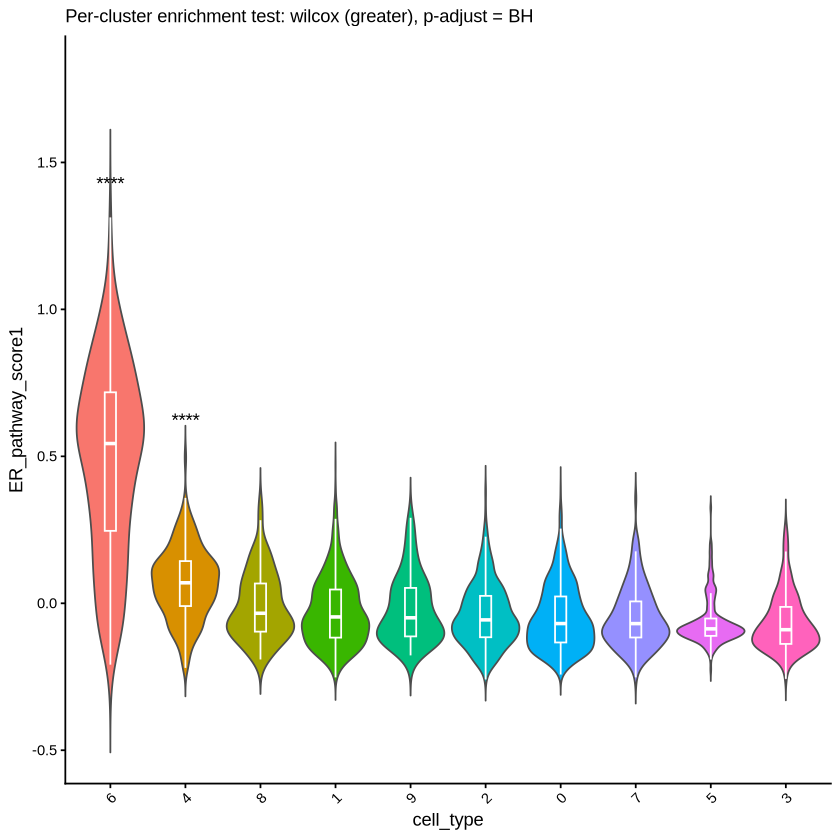

In [15]:
res <- plot_module_scores(
  object = global_analysis_out,
  seed_genes = seed_genes,
  module_name = "ER_pathway_score",
  assay_name = "RNA",
  cluster_name = "cell_type",
  test_method = "wilcox",     # or "t.test"
  alternative = "greater",    # enrichment = higher in cluster than others
  label_type = "stars",
  show_ns = FALSE
)

res$plot
res$stats
global_analysis_out <- res$object

# 1. begin with linking peaks

In [16]:
# combine priorGRN with seed genes and extrend by relevant marker genes for cluster
gene_name_2_gene_id <- read.csv("/nfs/data3/mopitas/mapra/TFnets/genename2EID.csv")

linking_peaks_for_module_cluster <- function(object, 
                                            seed_genes, 
                                            priorGRN, 
                                            cluster,
                                            gene_name_2_gene_id,
                                            log2FC_threshold = 5,
                                            p_adj_threshold = 0.05,
                                            genome=BSgenome.Hsapiens.UCSC.hg38,
                                            frag_path=NULL) {
    marker_genes_cluster <- object@misc$markers.annotated[
        !is.na(object@misc$markers.annotated[["cluster"]]) &
        !is.na(object@misc$markers.annotated[["p_val_adj"]]) &
        !is.na(object@misc$markers.annotated[["avg_log2FC"]]) &
        object@misc$markers.annotated[["avg_log2FC"]] > log2FC_threshold &
        object@misc$markers.annotated[["p_val_adj"]] < p_adj_threshold &
        object@misc$markers.annotated[["cluster"]] == cluster,
        ,
        drop = FALSE
    ]

    priorGRN <- priorGRN %>%
        rename(
            gene = gene_name,
            EID = Gene
        )

    priorGRN_ext <- gene_name_2_gene_id[gene_name_2_gene_id[["gene_name"]] %in% seed_genes, , drop = FALSE] %>%
    rename(
        gene = gene_name,
        EID = gene_id
    )
    priorGRN <- bind_rows(priorGRN, priorGRN_ext)


    object<-linking_peaks(object, priorGRN, seeds=marker_genes_cluster, genome=genome)
    if (!is.null(frag_path)) {
        frag_obj <- CreateFragmentObject(
            path = frag_path,
            cells = colnames(object)   # restrict to cells in this object
        )
        object[["peaks"]]@fragments <- list(frag_obj)
    }
    

    # plot links
    p <- plot_links_per_gene(object)
    return(list(object = object, plot_links = p, marker_genes_cluster=marker_genes_cluster, priorGRN=priorGRN))

}
   

[1] "Linking peaks to genes..."


Found gene coordinates for 32 genes

Testing 35 genes and 2094 peaks



[1] "Computing peak-gene distances..."
[1] "Filtering links for promoters..."
[1] "Annotating proximal/distal links..."


Computing hash



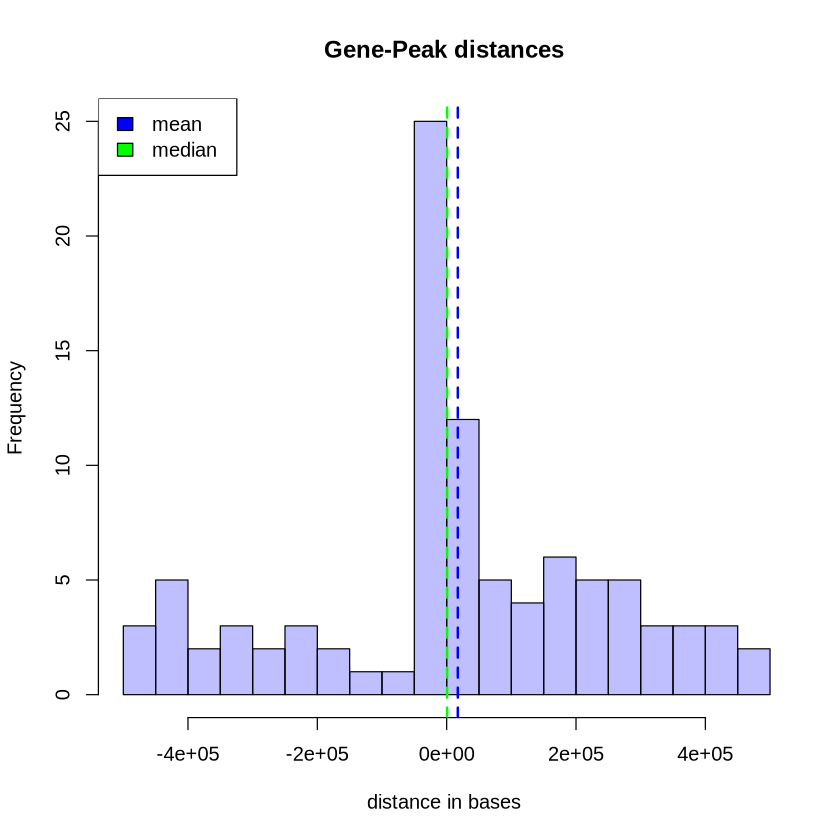

In [17]:
res_links <- linking_peaks_for_module_cluster(global_analysis_out, 
                                seed_genes, 
                                priorGRN, 
                                cluster="6",
                                gene_name_2_gene_id,
                                frag_path = "../swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz")

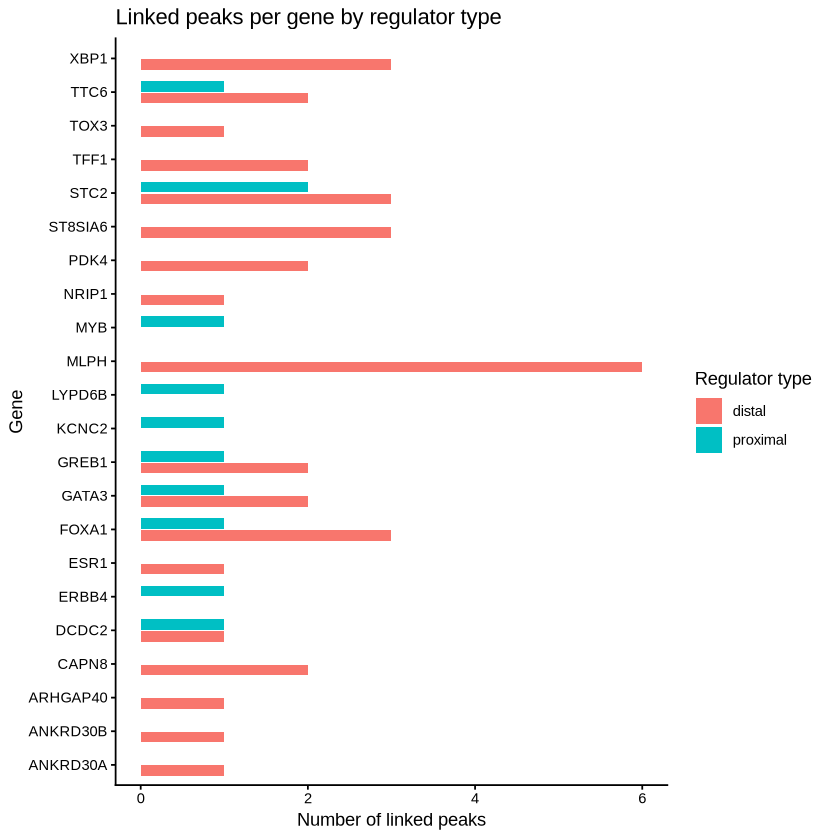

In [18]:
res_links$plot_links

In [19]:
coverage_plot_for_gene <- function(object, gene_name) {
    links <- Links(object[["peaks"]])
    links_gene <- links[links$gene == gene_name]
    print(links_gene)

    # the strand of the gene
    strand <- as.character(unique(strand(Annotation(res_links$object)[Annotation(res_links$object)$gene_name == "FOXA1"])))

    if ("+" %in% strand) {
        # if gene is on the + strand, upstream is left and downstream is right
        left_extend = abs(min(min(links_gene$distancePeakStartTSS),0))
        right_extend = abs(max(0,max(links_gene$distancePeakStartTSS)))
    } else {
        # if gene is on the - strand, upstream is right and downstream is left
        left_extend = abs(max(0,max(links_gene$distancePeakStartTSS)))
        right_extend = abs(min(0,min(links_gene$distancePeakStartTSS)))
    }
    
    p <- CoveragePlot(
        object = object,
        region = gene_name,
        features = gene_name,
        expression.assay = "RNA",
        #idents = idents.plot,
        extend.upstream = left_extend, # left
        extend.downstream = right_extend, # right
        annotation = TRUE,
        peaks = TRUE,
        tile = TRUE,
        links = TRUE
        )
    return(p)
}

GRanges object with 3 ranges and 8 metadata columns:
      seqnames            ranges strand |     score        gene
         <Rle>         <IRanges>  <Rle> | <numeric> <character>
  [1]    chr14 37584360-37595847      * | 0.2142613        TTC6
  [2]    chr14 37595269-37595847      * | 0.1889693        TTC6
  [3]    chr14 37595847-37622555      * | 0.0967467        TTC6
                        peak    zscore      pvalue distancePeakStartTSS
                 <character> <numeric>   <numeric>            <numeric>
  [1] chr14-37583386-37585..   7.00541 1.23130e-12               -12461
  [2] chr14-37594269-37596..   7.43702 5.14891e-14                -1578
  [3] chr14-37622140-37622..   2.25498 1.20674e-02                26293
      distancePeakEndTSS regulatorType
               <numeric>   <character>
  [1]             -10514        distal
  [2]                422      proximal
  [3]              27122        distal
  -------
  seqinfo: 15 sequences from an unspecified genome; no seqleng

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 3.5 GiB"
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


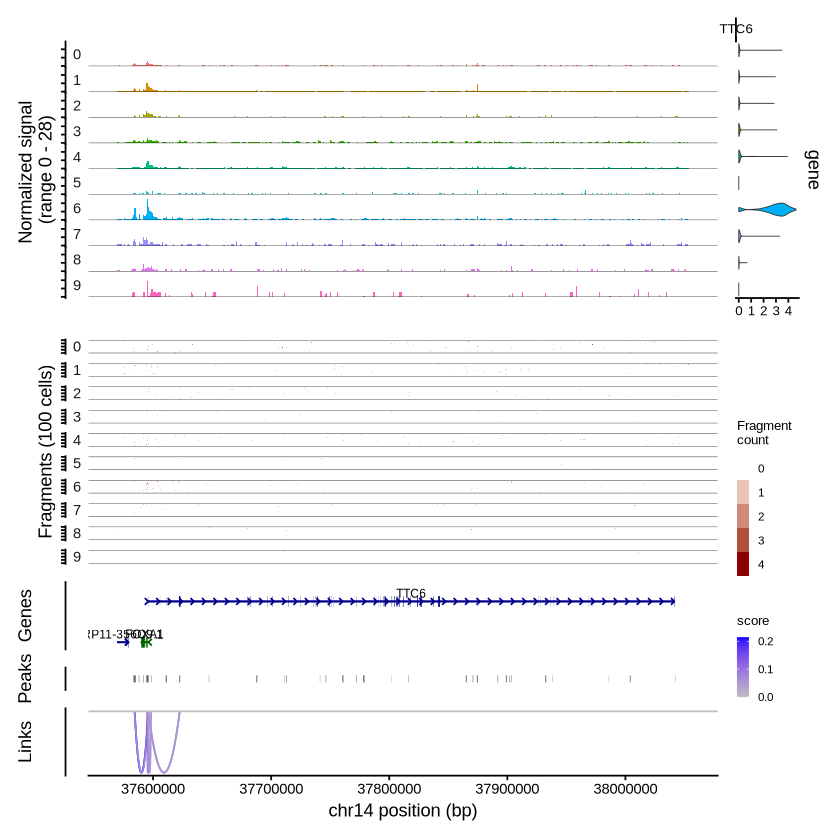

In [20]:
coverage_plot_for_gene(res_links$object, "TTC6")

GRanges object with 4 ranges and 8 metadata columns:
      seqnames            ranges strand |     score        gene
         <Rle>         <IRanges>  <Rle> | <numeric> <character>
  [1]    chr14 37584360-37596059      * | 0.0742451       FOXA1
  [2]    chr14 37595269-37596059      * | 0.0758218       FOXA1
  [3]    chr14 37596059-37598359      * | 0.0556764       FOXA1
  [4]    chr14 37596059-37622555      * | 0.0516014       FOXA1
                        peak    zscore      pvalue distancePeakStartTSS
                 <character> <numeric>   <numeric>            <numeric>
  [1] chr14-37583386-37585..   3.65003 1.31107e-04                10660
  [2] chr14-37594269-37596..   3.95954 3.75468e-05                 -276
  [3] chr14-37598166-37598..   2.61780 4.42492e-03                -2558
  [4] chr14-37622140-37622..   2.37761 8.71252e-03               -26976
      distancePeakEndTSS regulatorType
               <numeric>   <character>
  [1]              12607        distal
  [2]         

Warning message:
"Removed 109 rows containing missing values or values outside the scale range
(`geom_segment()`)."


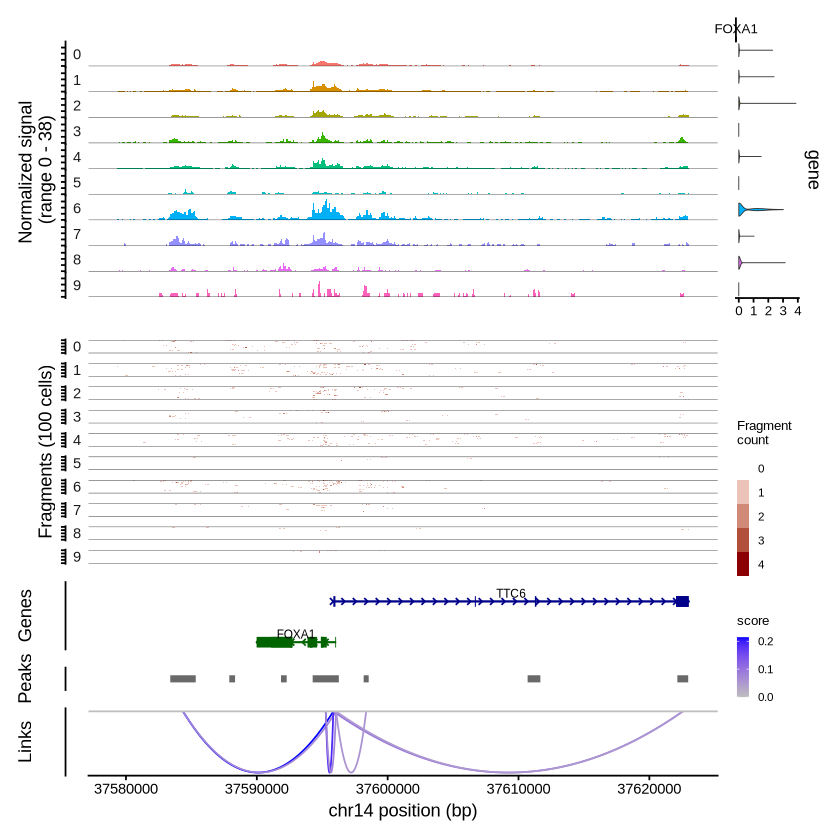

In [21]:
coverage_plot_for_gene(res_links$object, "FOXA1")

# 2. identify cluster specific peaks

In [ ]:
#understand what peak stants does 
# adds object@misc$peak_stats
# adds filtered version: object@misc$df.stats.filtered

In [22]:
marker_df <- data.frame(
  cluster = res_links$marker_genes_cluster[["cluster"]],
  gene = res_links$marker_genes_cluster[["gene"]],
  annotation = res_links$marker_genes_cluster[["annotation"]],
  stringsAsFactors = FALSE
)

module_df <- data.frame(
  cluster ="6",
  gene = unique(res_links$priorGRN[["gene"]]),
  annotation = "module_genes",
  stringsAsFactors = FALSE
)

seeds_for_peaks_stats <- rbind(marker_df, module_df)

In [23]:
seeds_for_peaks_stats

cluster,gene,annotation
<chr>,<chr>,<chr>
6,KCNC2,marker.pos.6
6,MYB,marker.pos.6
6,ANKRD30A,marker.pos.6
6,TTC6,marker.pos.6
6,KIF12,marker.pos.6
6,ARHGAP40,marker.pos.6
6,ANKRD30B,marker.pos.6
6,DCDC2,marker.pos.6
6,TOX3,marker.pos.6


In [25]:
source("../multiome_methods/peak_gene_relations.r")

In [26]:

# seeds here needs: gene, cluster, annotation
res_peak_stats <-do_peak_stats(object=res_links$object, seeds=seeds_for_peaks_stats)

[1] "Writing peak stats table..."
[1] "Conducting cluster specific statistical tests..."
[1] "Calculating zero expression stats..."
[1] "Clustering peaks for bg distributions..."
[1] "Counting peaks per seed..."
[1] "Filtering peak stats..."
[1] "Number of linked peaks after filtering: 22"

cluster_specific           global 
              20                2 


In [27]:
options(repr.plot.width=15, repr.plot.height=8)

In [ ]:


plot_score_distributions <- function(df, ncol = 4, bins = 50, log10_p = TRUE) {
  
  num_df <- df %>%
    dplyr::select(where(is.numeric))
  
  # optionally make p-value columns easier to inspect
  if (log10_p) {
    p_cols <- grep("pvalue|p.value|_p$", colnames(num_df), value = TRUE)
    for (cc in p_cols) {
      num_df[[paste0("minus_log10_", cc)]] <- -log10(pmax(num_df[[cc]], 1e-300))
    }
  }
  
  plot_df <- num_df %>%
    pivot_longer(cols = everything(), names_to = "score", values_to = "value") %>%
    filter(is.finite(value))
  
  ggplot(plot_df, aes(x = value)) +
    geom_histogram(bins = bins, fill = "grey70", color = "white") +
    facet_wrap(~ score, scales = "free", ncol = ncol) +
    theme_classic() +
    labs(x = NULL, y = "Count", title = "Distributions of peak-stat scores")
}


In [29]:
peak_stats <- res_peak_stats@misc$peak_stats.filtered

In [30]:
View(head(peak_stats[30:45]))

,acc_not_0.all,expr_not_0.given_acc.all,expr_and_acc_not_0.all,FC.expr_given_acc.all,expr_not_0.bg_other_peaks.all,acc_not_0.bg_other_peaks.all,expr_not_0.given_acc.bg_other_peaks.all,expr_and_acc_not_0.bg_other_peaks.all,FC.expr_given_acc.bg_other_peaks.all,n.bg_other_peaks.all,high_cor_distal,high_cor_distal_zScore,promotersLinkedToSeed,distalPeaksLinkedToSeed,acc_cells_cluster,delta_expr_given_acc.same_peak_bg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>,<chr>,<table[1d]>,<dbl>
1,0.04789272,0.10000000,0.004789272,4.461538,NA,NA,NA,NA,NA,0,NA,NA,1,0,32,0.7095757
2,0.30210728,0.03107166,0.009386973,1.544705,NA,NA,NA,NA,NA,0,NA,NA,1,0,95,0.5045884
9,0.20938697,0.10338518,0.021647510,2.286740,0.04521073,0.0710728,0.1433578,0.01005747,3.170881,2,NA,NA,1,2,96,0.8915914
12,0.03390805,0.14689266,0.004980843,3.249066,0.04521073,0.1588123,0.1216041,0.01839080,2.689718,2,NA,NA,1,2,21,0.9679487
16,0.15498084,0.03337454,0.005172414,1.707991,0.01954023,0.1214559,0.0362776,0.00440613,1.856560,1,NA,NA,1,1,51,0.4038491
18,0.13045977,0.04552129,0.005938697,2.140731,NA,NA,NA,NA,NA,0,NA,NA,1,0,63,0.4046078


✓ percentage of cells with expression and accessibility
- in cluster: `expr_and_acc_not_0`
- in all clusters: `expr_and_acc_not_0.all`

✓ prob of expression given accessibility increased by peak access: expr_not_0.given_acc / expr_not_0
- `FC.expr_given_acc`
- `FC.expr_given_acc.all`

✓ higher in cluster than in bg clusters, if: delta_expr_given_acc.same_peak_bg>0
- `delta_expr_given_acc.same_peak_bg` =  `object@misc$peak_stats$expr_not_0.given_acc.bg` -  `expr_not_0.given_acc`



for cluster specific:
- p.value-t.test_highly.acc_BH`<p_value_cutoff
- expr_and_acc_not_0 > th (percentage )
- FC.expr_given_acc > th, eg 2
maybe: 
- delta_expr_given_acc.same_peak_bg > 0
- min cells w/ expression 30

for global:
- p.value-t.test_highly.acc_BH`<p_value_cutoff
- expr_and_acc_not_0.all > th
- FC.expr_given_acc.all > th 
maybe:
- min cells w/ expression 30




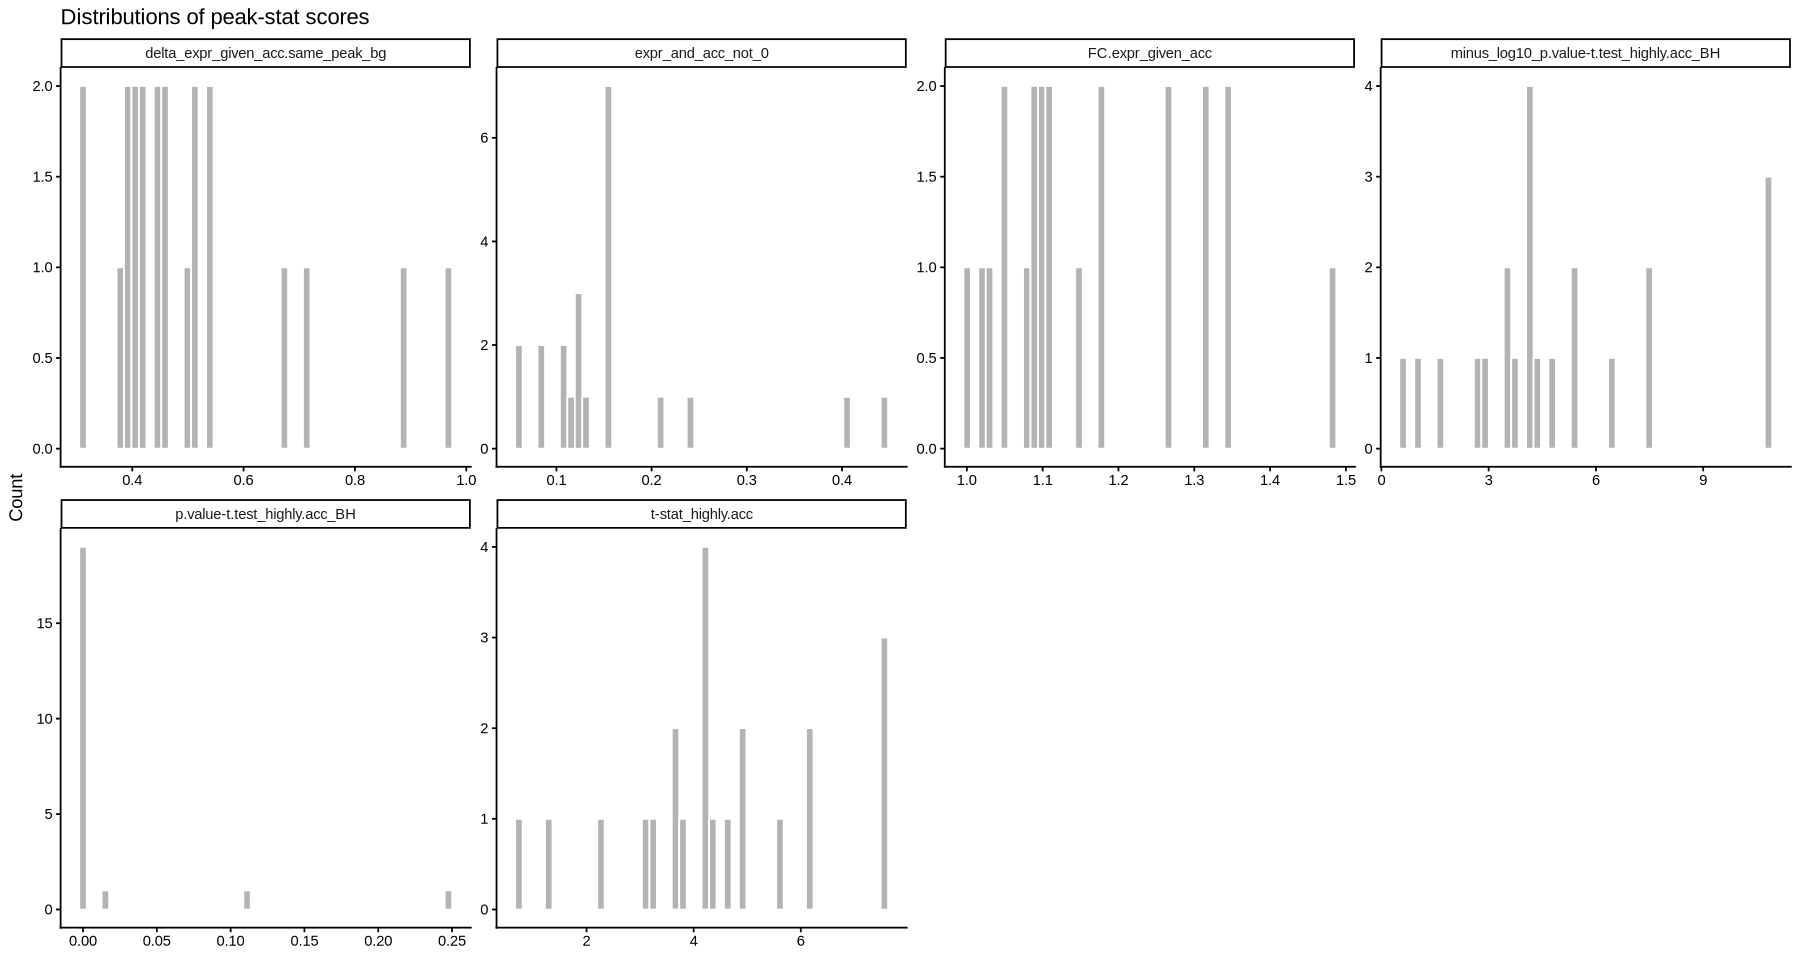

In [31]:


score_cols <- c(
  "p.value-t.test_highly.acc_BH",
  "t-stat_highly.acc",
  "expr_and_acc_not_0",
  "FC.expr_given_acc",
  "delta_expr_given_acc.same_peak_bg"
)

plot_score_distributions(peak_stats[, score_cols, drop = FALSE])

In [32]:
summary(peak_stats)

   cluster              peak               gene            annotation       
 Length:22          Length:22          Length:22          Length:22         
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
 regulatorType      signac.scores     signac.zscores  signac.pvalues    
 Length:22          Min.   :0.05191   Min.   :1.654   Min.   :0.000000  
 Class :character   1st Qu.:0.05705   1st Qu.:1.962   1st Qu.:0.000220  
 Mode  :character   Median :0.06699   Median :2.674   Median :0.003749  
                    Mean   :0.07222   Mean   :2.852   Mean   :0.012853  
                   

# 3. do local motif stats

- adds to:
    - object@misc$motifs.inProximalPeaks
    - object@misc$motifs.inDistalPeaks

In [34]:
seeds_for_peaks_stats[14:14,]

,cluster,gene,annotation
,<chr>,<chr>,<chr>
14,6,FOXA1,marker.pos.6


In [35]:
res_local_motif_stats <- do_local_motif_stats(object=res_peak_stats, 
                               seeds=seeds_for_peaks_stats[14:14,],
                               fragpath=NULL,
                               peaks_assay='peaks',
                               background_size=100,
                               min_count=1, min_log2FC=1, max_t_stat=0, min_p_adjust=0.05)

Calculating motif enrichment

counting motifs in linked peaks



[1] 1
[1] 1
[1] "2026-04-02 14:59:58 CEST"


computing which motif ranges in proximal peaks associated to gene

computing motifs to gene



computing which motif ranges in distal peaks associated to gene

computing motifs to gene

computed motif count



[1] "chr14-37594269-37596269" "chr14-37594269-37596269"


counting motifs in promoter region

Filtering motif enrichment

Adding footprint stats

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."
Detected 160 cores. Using 8 cores for parallel processing.

Attempting parallelized processing for 193 Seed-motif pairs. Using 8 cores.

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

computing 100 background footprints

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing base compositi

[1] "2026-04-02 15:28:14 CEST"
GRanges object with 3 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595905-37595910      + |    9.6718
  [2]    chr14 37595686-37595691      - |    9.6718
  [3]    chr14 37595788-37595793      - |    9.6718
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-02 15:28:15 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


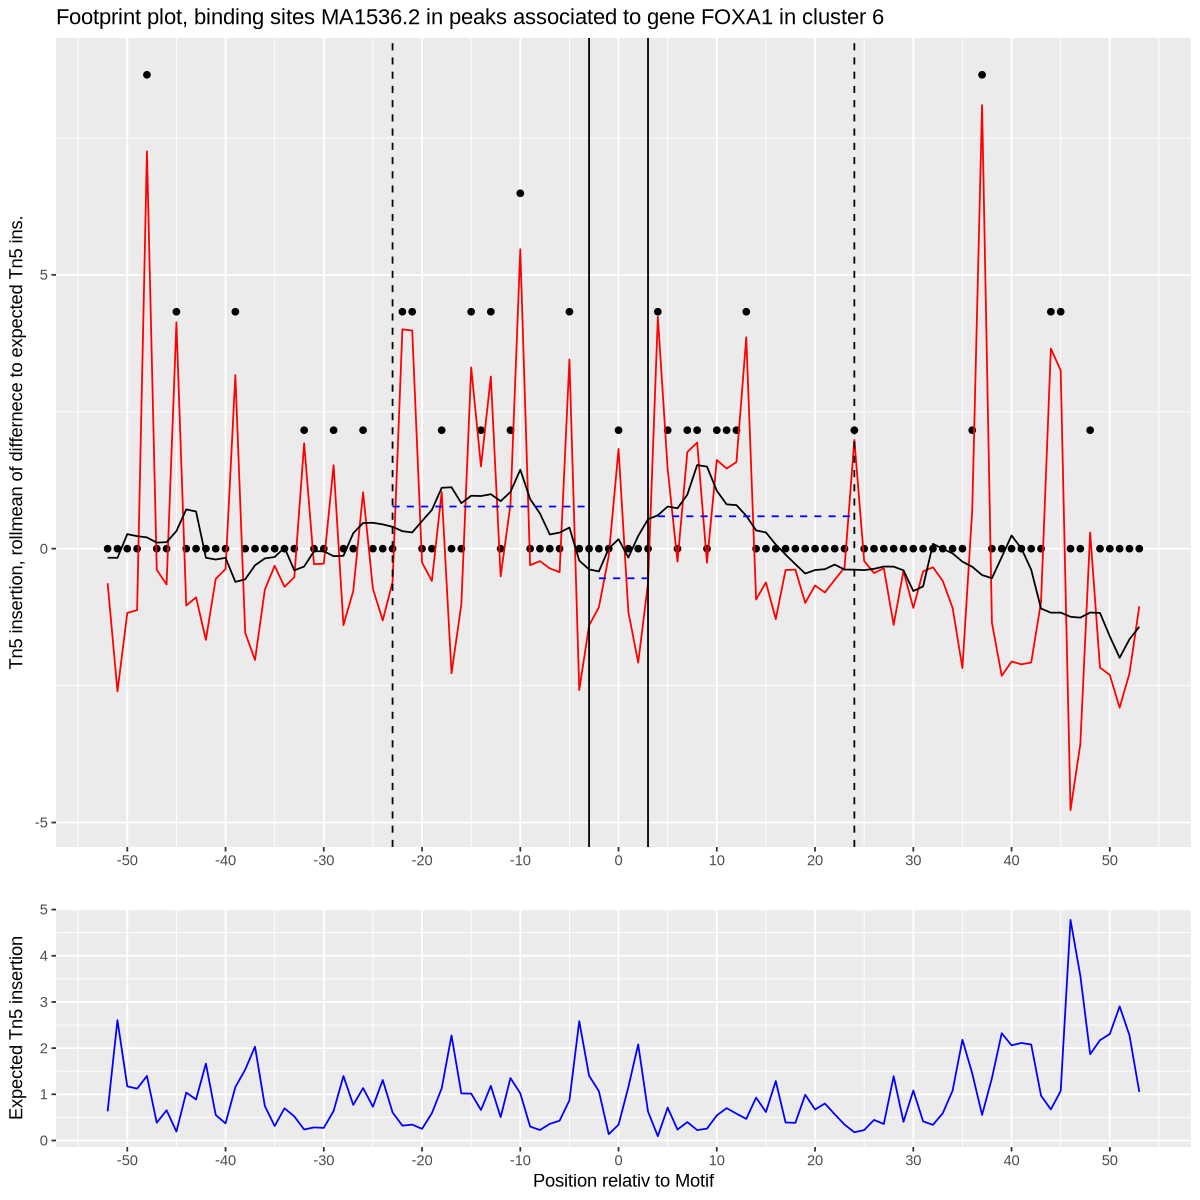

In [45]:

footprint_plots_by_TF(object=res_local_motif_stats, gene='FOXA1', cluster=6, motif_id='MA1536.2', path=NULL)

[1] "2026-04-02 15:32:20 CEST"
GRanges object with 4 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595142-37595155      + |   19.3589
  [2]    chr14 37595145-37595158      + |   21.7902
  [3]    chr14 37595148-37595161      + |   17.7851
  [4]    chr14 37595188-37595201      + |   13.5588
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-02 15:32:20 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


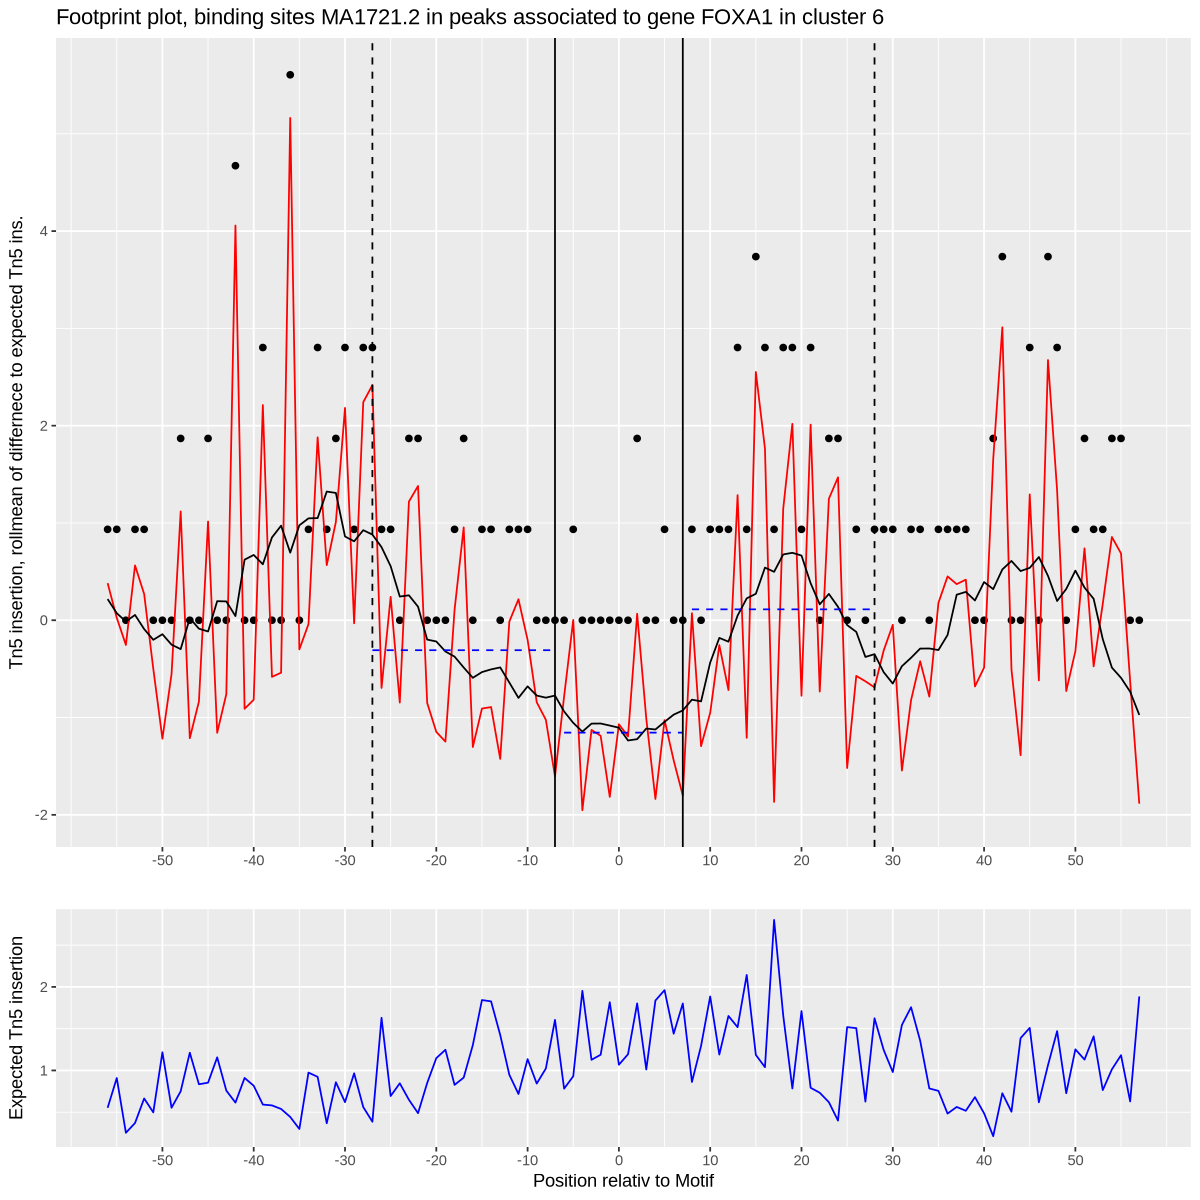

In [49]:

footprint_plots_by_TF(object=res_local_motif_stats, gene='FOXA1', cluster=6, motif_id='MA1721.2', path=NULL)

# 4. Map motifs to TFs

In [46]:

res_motifs_mapped<-add_motif_TF_mapping(res_local_motif_stats)

# 5. draw network

In [52]:
colnames(priorGRN)[colnames(priorGRN) == "gene_name"] <- "gene"
priorGRN

Gene,TF,Breast,TS_Breast,net_Breast,expTS_Breast,gene
<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>
ENSG00000100219,RFX5,0.41847,1,0.41847,1,XBP1
ENSG00000107485,KLF3,5.66960,1,5.66960,1,GATA3
ENSG00000129514,VENTX,0.35413,1,0.35413,1,FOXA1
ENSG00000129514,FOXK1,0.89098,1,0.89098,1,FOXA1
ENSG00000129514,TCF7,0.34937,1,0.34937,1,FOXA1


In [54]:
saveRDS(res_motifs_mapped, "res_motifs_mapped.rds")

In [93]:
source("../multiome_methods/TF_activity.r")

## read obj 

In [8]:
# use output of global motif analysis
res_motifs_mapped <- readRDS("res_motifs_mapped.rds")

In [139]:
if ("gene_name" %in% colnames(priorGRN)) {
    priorGRN <- dplyr::rename(priorGRN, gene = gene_name)
}

In [140]:
priorGRN[3:5,]

,Gene,TF,Breast,TS_Breast,net_Breast,expTS_Breast,gene
,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>
3,ENSG00000129514,VENTX,0.35413,1,0.35413,1,FOXA1
4,ENSG00000129514,FOXK1,0.89098,1,0.89098,1,FOXA1
5,ENSG00000129514,TCF7,0.34937,1,0.34937,1,FOXA1


### actual call 

In [230]:
res_motifs_mapped@misc$tf_stats <-NULL

In [244]:
source("../multiome_methods/TF_activity.r")

[1] "include_motifs_for_seed: FOXA1 6"
[1] "motif stats for seed:FOXA16"
[1] 193  24
[1] "motif stats for seed:FOXA16"
[1] 103  24


found and passed 101 Transcription factors that bind in regulatory regions for seed FOXA1 6



[1] "VENTX"


adding distal and not enriched motif_stats for:



[1] "FOXA1 6"


...

[1] "TFDP1"
[1] "TLX2"
[1] "UNCX"
[1] "ZBTB12"
[1] "ZBTB14"
[1] "ZIM3"
[1] "ZNF189"
[1] "ZNF682"
[1] "ZNF684"
[1] "ZNF93"


colors are numbers at the end: is this going wrong here already?



 [1] blue   blue   blue   red    yellow yellow yellow yellow yellow yellow
[11] red    yellow yellow red    yellow yellow red    red    red    yellow
[21] red    yellow red    red    red    yellow yellow yellow red    yellow
[31] red    red    yellow yellow yellow yellow yellow yellow yellow yellow
[41] red    red    red    red    red    yellow red    yellow red    yellow
[51] yellow yellow red    yellow red    red    red    yellow yellow red   
[61] red    red    red    red    green  green  red    yellow yellow yellow
[71] yellow red    yellow yellow yellow yellow red    red    yellow red   
[81] red    yellow yellow green  yellow yellow red    red    red    red   
[91] red    yellow red    red    yellow green 
Levels: green yellow red blue black gray


edge_color at the end of get_subnetwork



 [1] blue   blue   blue   red    yellow yellow yellow yellow yellow yellow
[11] red    yellow yellow red    yellow yellow red    red    red    yellow
[21] red    yellow red    red    red    yellow yellow yellow red    yellow
[31] red    red    yellow yellow yellow yellow yellow yellow yellow yellow
[41] red    red    red    red    red    yellow red    yellow red    yellow
[51] yellow yellow red    yellow red    red    red    yellow yellow red   
[61] red    red    red    red    green  green  red    yellow yellow yellow
[71] yellow red    yellow yellow yellow yellow red    red    yellow red   
[81] red    yellow yellow green  yellow yellow red    red    red    red   
[91] red    yellow red    red    yellow green 
Levels: green yellow red blue black gray
            from    to  color priorTF reg_type in.prom
FOXA1.1    VENTX FOXA1   blue    TRUE        2       3
FOXA1.2    FOXK1 FOXA1   blue    TRUE        2       3
FOXA1.3     TCF7 FOXA1   blue    TRUE        2       3
FOXA1.4    INSM1 

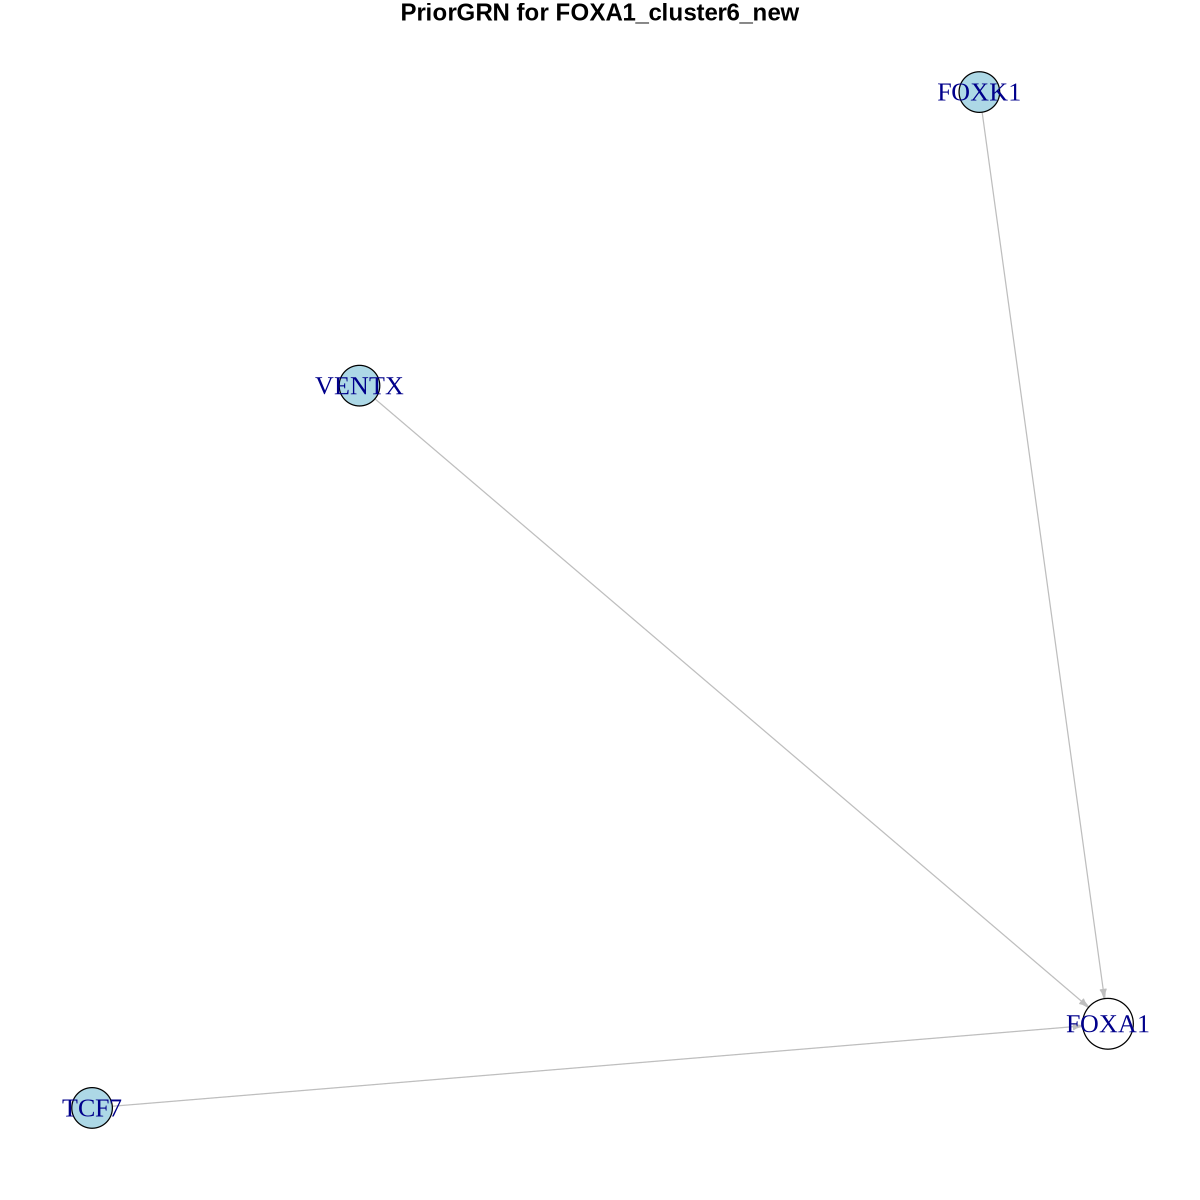

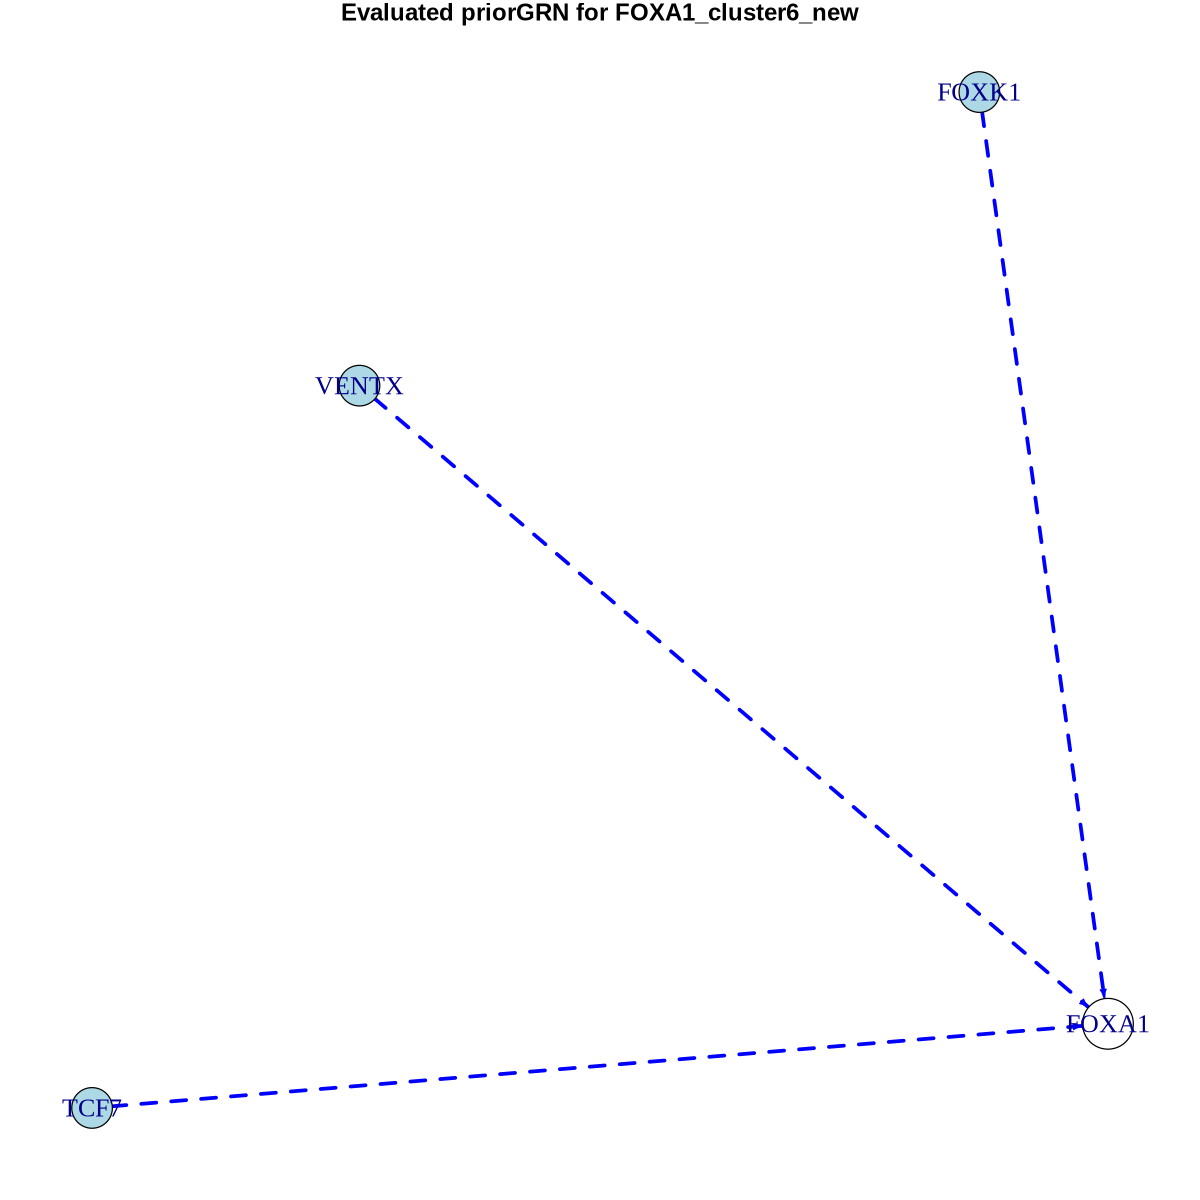

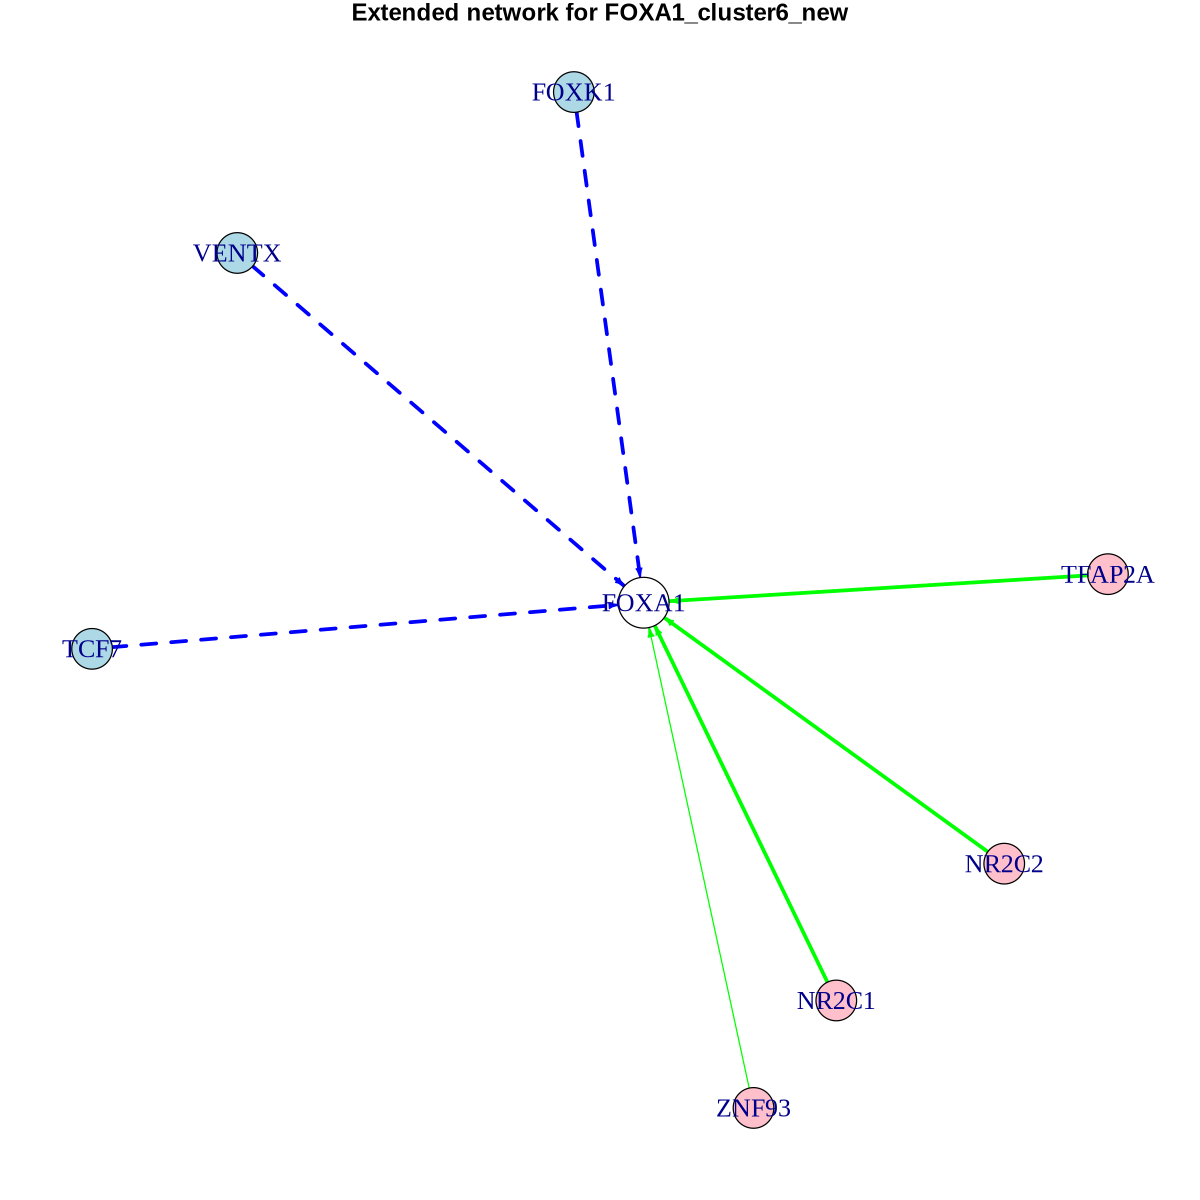

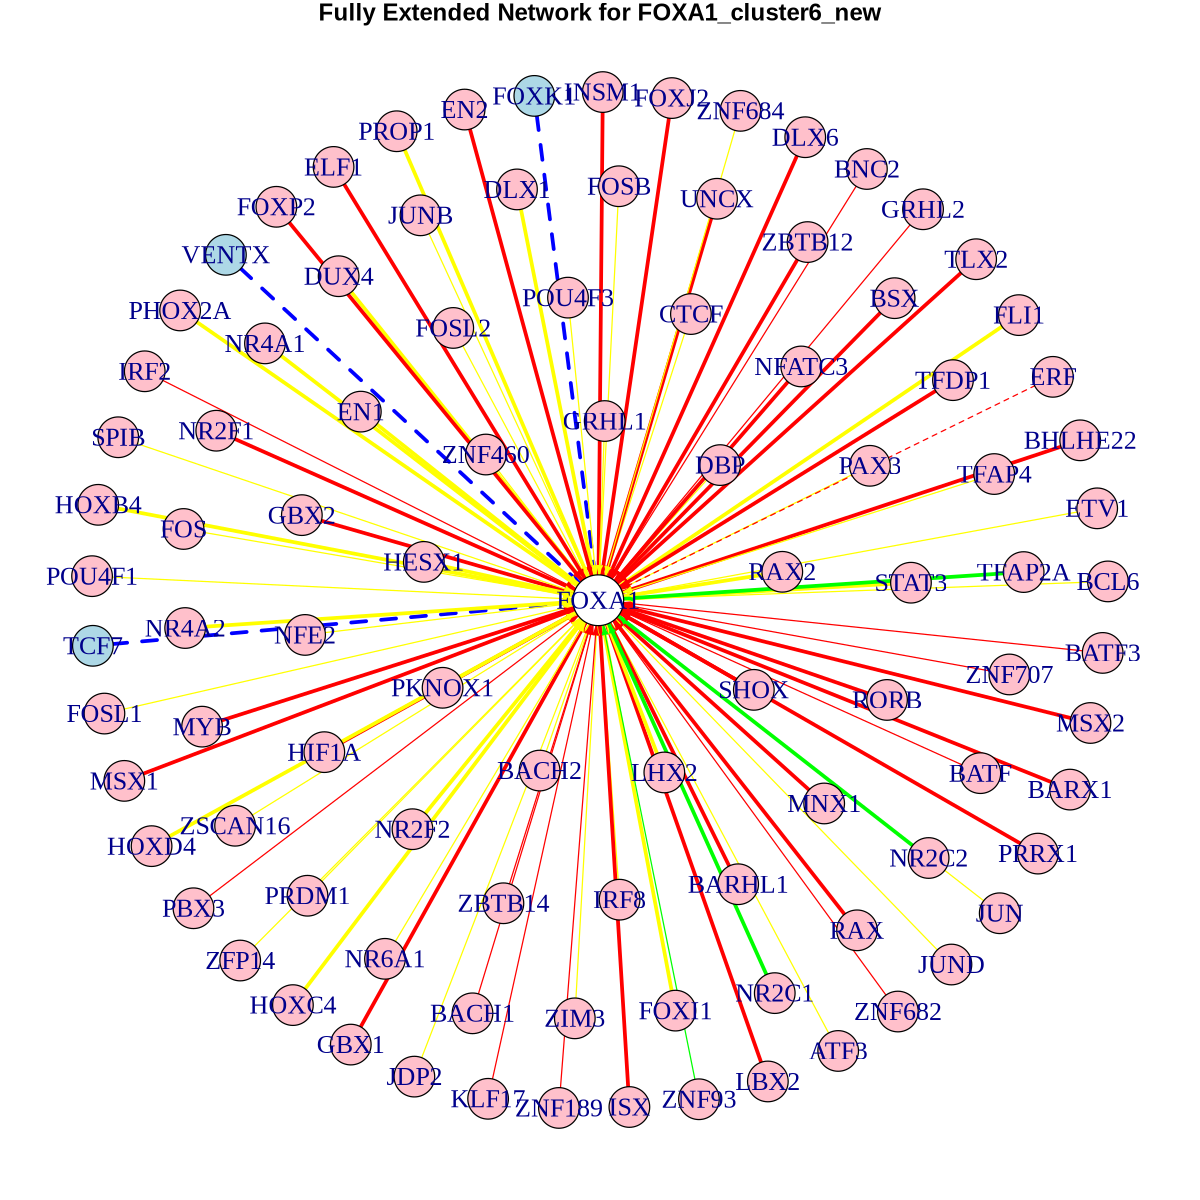

In [245]:
object_w_net<-draw_subNetwork_for_context(object=res_motifs_mapped, 
        gene_list= c("FOXA1"),
        cluster="6", 
        priorGRN=priorGRN[3:5,],
        context_name='FOXA1_cluster6_new',resolution=20,pointsize=50
        )

In [240]:
green_motifs <- object_w_net@misc$seedNetwork$FOXA1_cluster6_new$FOXA1[object_w_net@misc$seedNetwork$FOXA1_cluster6_new$FOXA1$result=="green",]$motif

In [246]:
green_TFs <- object_w_net@misc$seedNetwork$FOXA1_cluster6_new$FOXA1[object_w_net@misc$seedNetwork$FOXA1_cluster6_new$FOXA1$result=="green",]$TF

In [247]:
green_TFs

[1] "NR2C1"  "NR2C2"  "TFAP2A" "ZNF93"

In [255]:
source("../multiome_methods/binding_site_identification.r")

[1] "NR2C1"


TF provided, plotting all motifs for TF



[1] "2026-04-03 15:07:14 CEST"
GRanges object with 3 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595905-37595910      + |   10.8605
  [2]    chr14 37595686-37595691      - |   10.8605
  [3]    chr14 37595788-37595793      - |   10.8605
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 15:07:14 CEST"


...

[1] "2026-04-03 15:07:15 CEST"
GRanges object with 2 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595434-37595447      - |   13.8025
  [2]    chr14 37595448-37595461      - |   11.7994
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 15:07:15 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


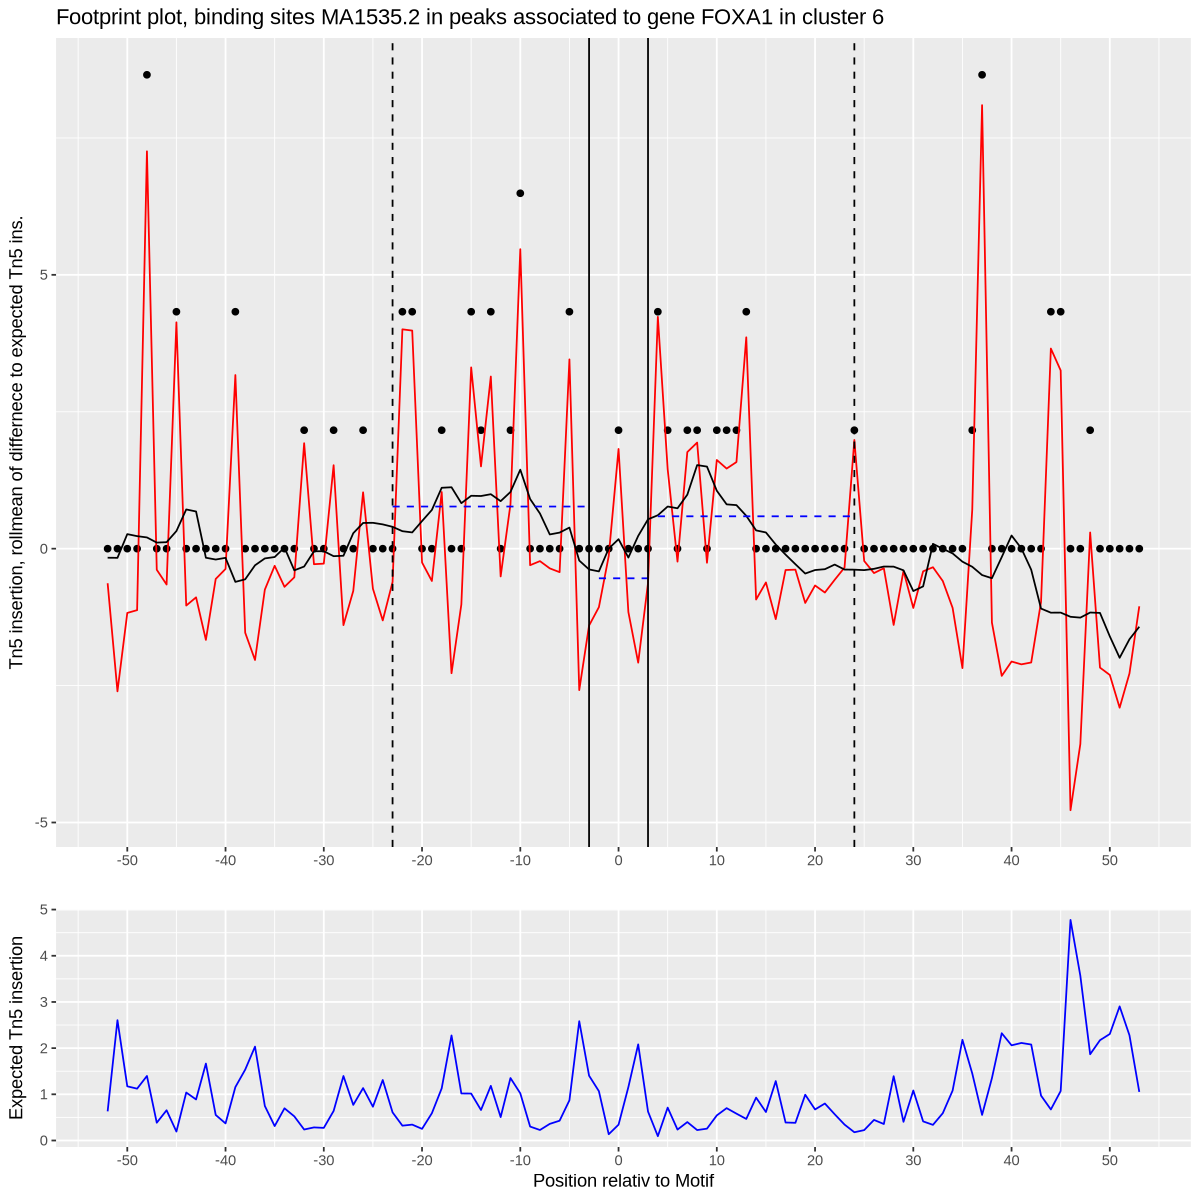

[1] "TFAP2A"


TF provided, plotting all motifs for TF



[1] "NO MOTIFS FOR TFAP2A FOUND IN PEAKS LINKED TO FOXA1"
[1] "ZNF93"


TF provided, plotting all motifs for TF



[1] "2026-04-03 15:07:16 CEST"
GRanges object with 4 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595142-37595155      + |   19.3589
  [2]    chr14 37595145-37595158      + |   21.7902
  [3]    chr14 37595148-37595161      + |   17.7851
  [4]    chr14 37595188-37595201      + |   13.5588
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 15:07:16 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


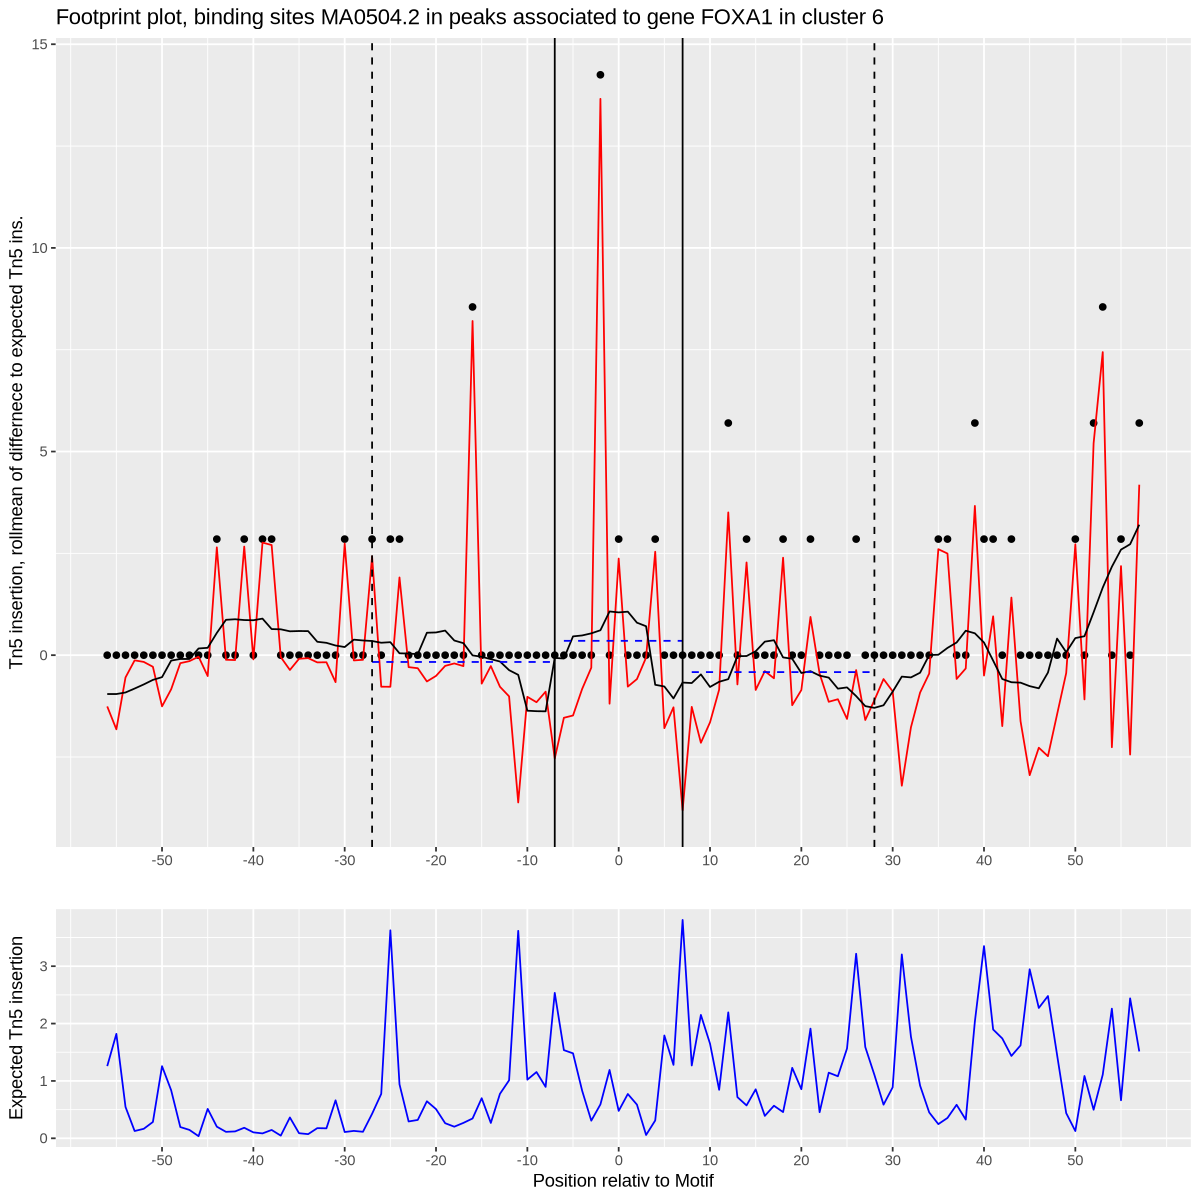

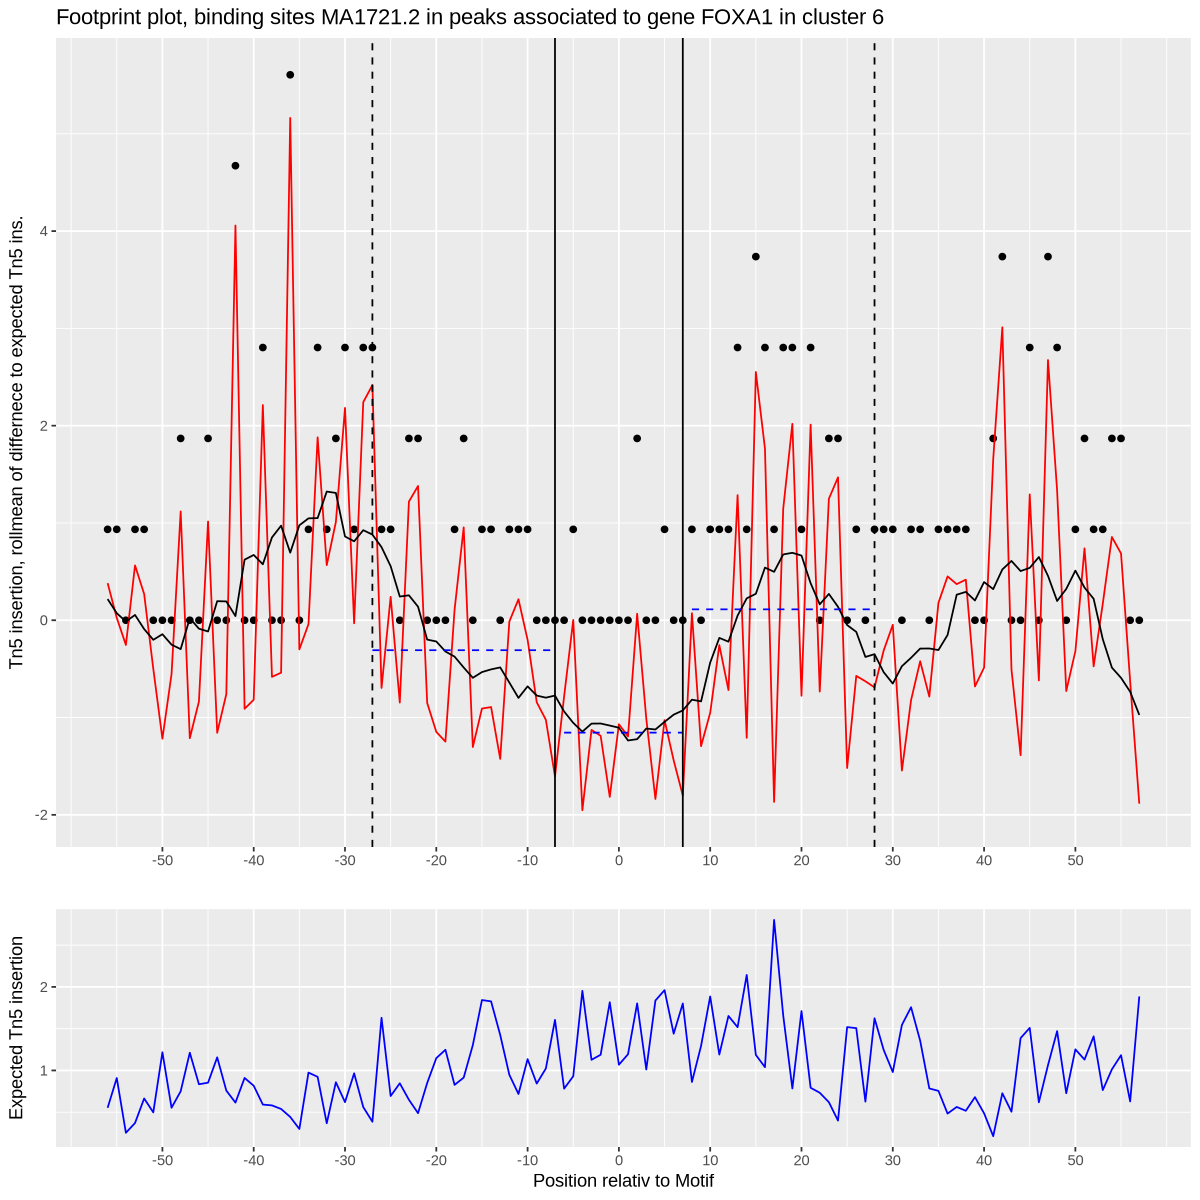

In [257]:

for(tf in green_TFs){
    print(tf)
    res <- footprint_plots_by_TF(object=object_w_net, gene='FOXA1', cluster=6, TF=tf, path=NULL)

    print(res)
}


[1] "2026-04-03 14:46:19 CEST"
GRanges object with 3 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595905-37595910      + |   10.8605
  [2]    chr14 37595686-37595691      - |   10.8605
  [3]    chr14 37595788-37595793      - |   10.8605
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 14:46:19 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"
[1] "2026-04-03 14:46:20 CEST"
GRanges object with 3 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595905-37595910      + |    9.6718
  [2]    chr14 37595686-37595691      - |    9.6718
  [3]    chr14 37595788-37595793      - |    9.6718
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 14:46:20 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


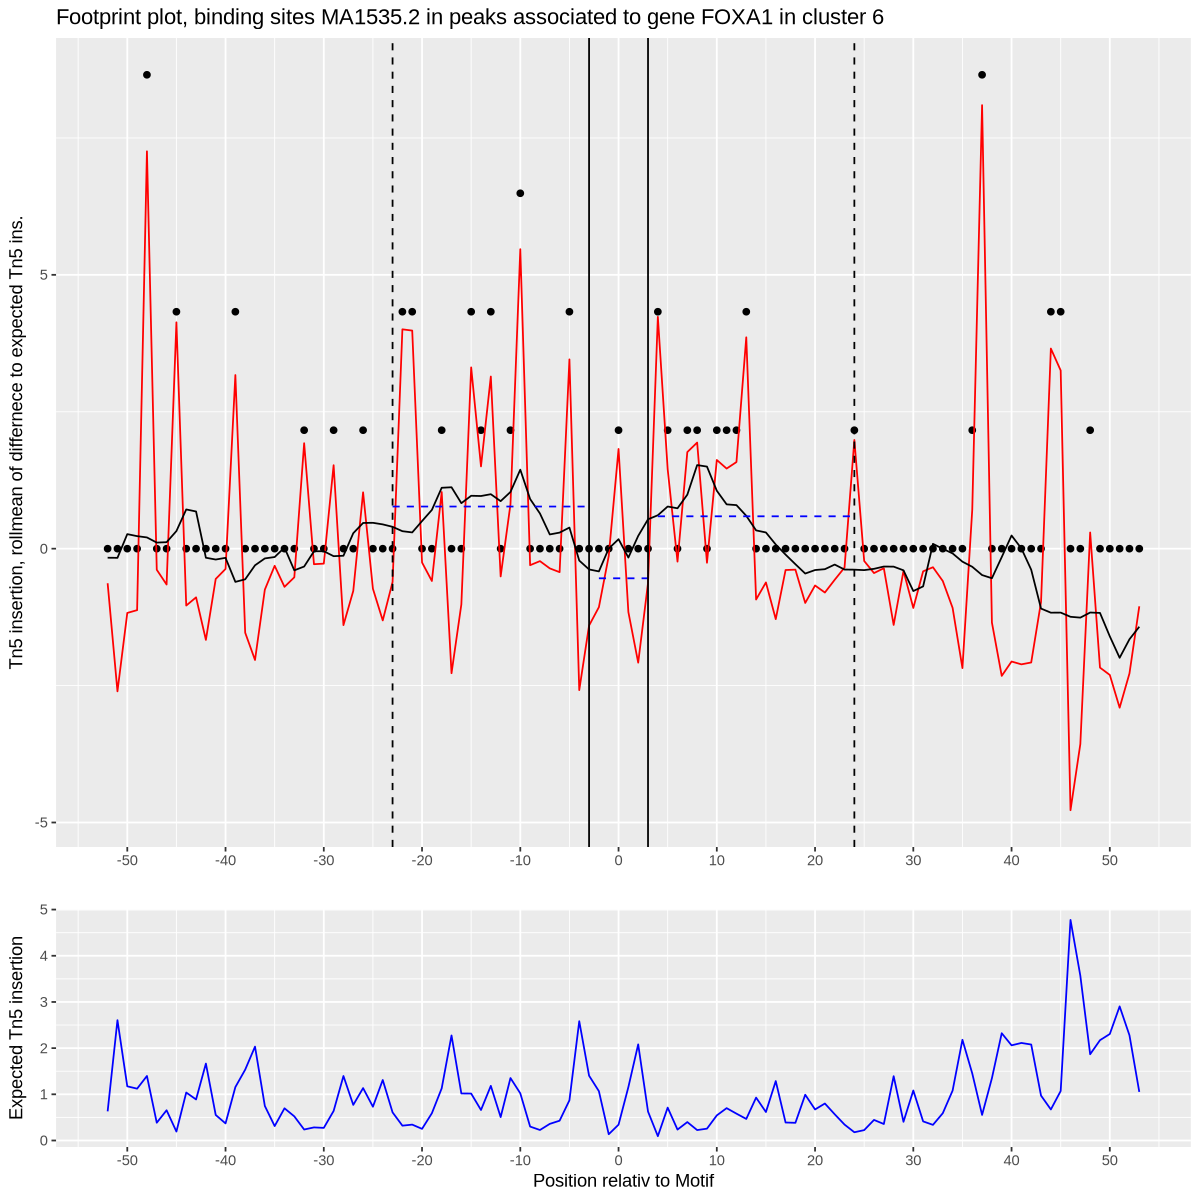

[1] "2026-04-03 14:46:21 CEST"
GRanges object with 2 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37594792-37594802      + |   13.7948
  [2]    chr14 37595635-37595645      - |   13.7948
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 14:46:21 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


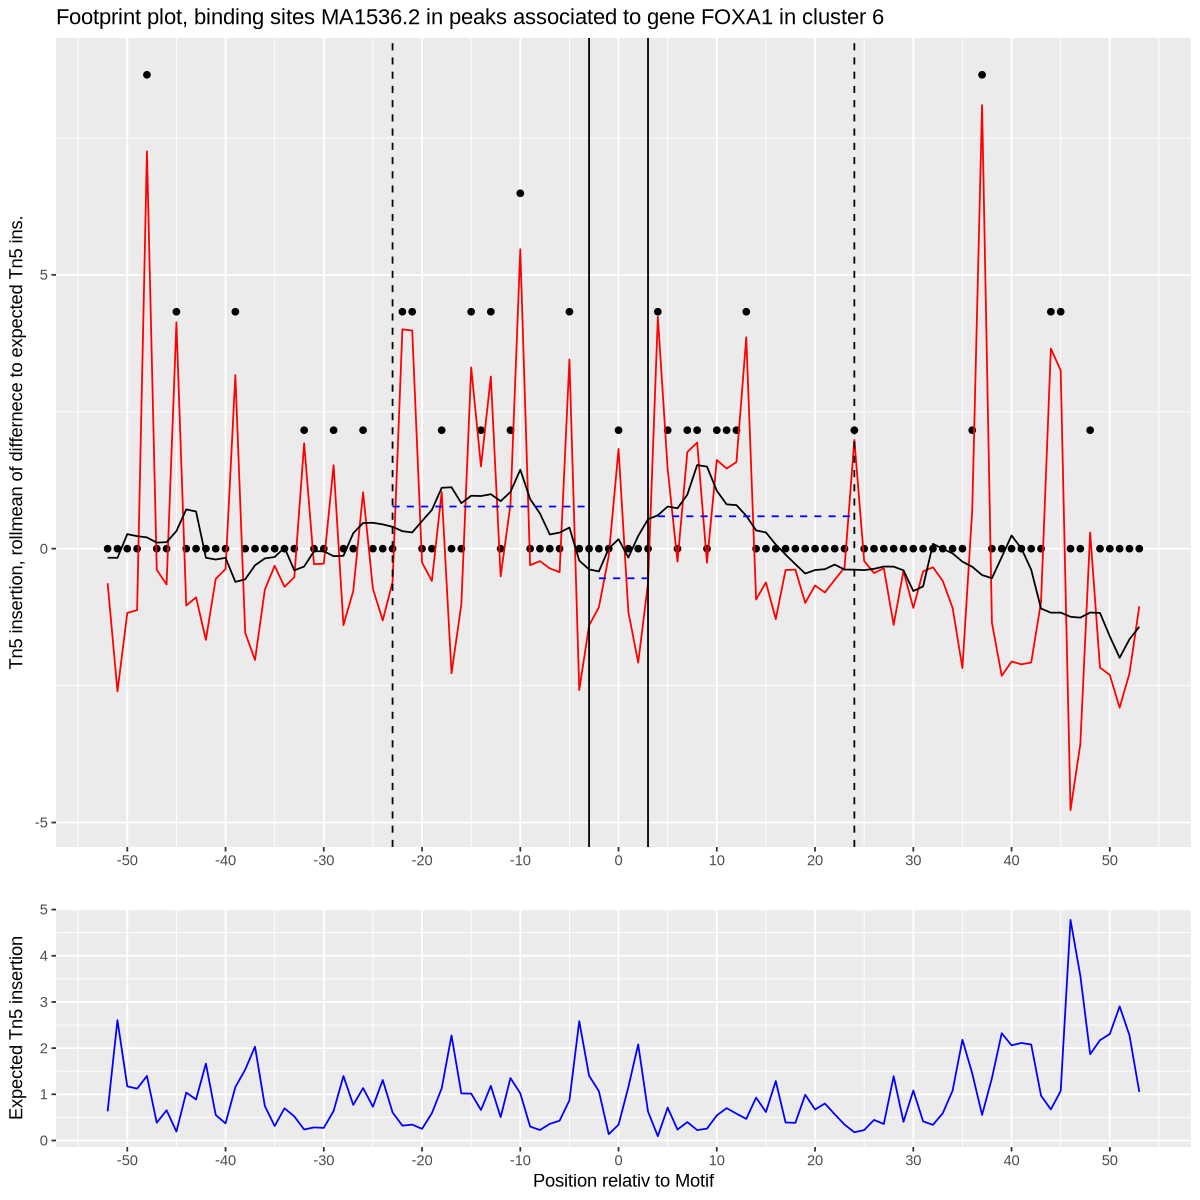

[1] "2026-04-03 14:46:21 CEST"
GRanges object with 4 ranges and 1 metadata column:
      seqnames            ranges strand |     score
         <Rle>         <IRanges>  <Rle> | <numeric>
  [1]    chr14 37595142-37595155      + |   19.3589
  [2]    chr14 37595145-37595158      + |   21.7902
  [3]    chr14 37595148-37595161      + |   17.7851
  [4]    chr14 37595188-37595201      + |   13.5588
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths


Computing base composition at motif sites

Computing expected Tn5 insertions per base



[1] "2026-04-03 14:46:22 CEST"


Finding + strand cut sites

Finding - strand cut sites



[1] 1
[1] "1 1"


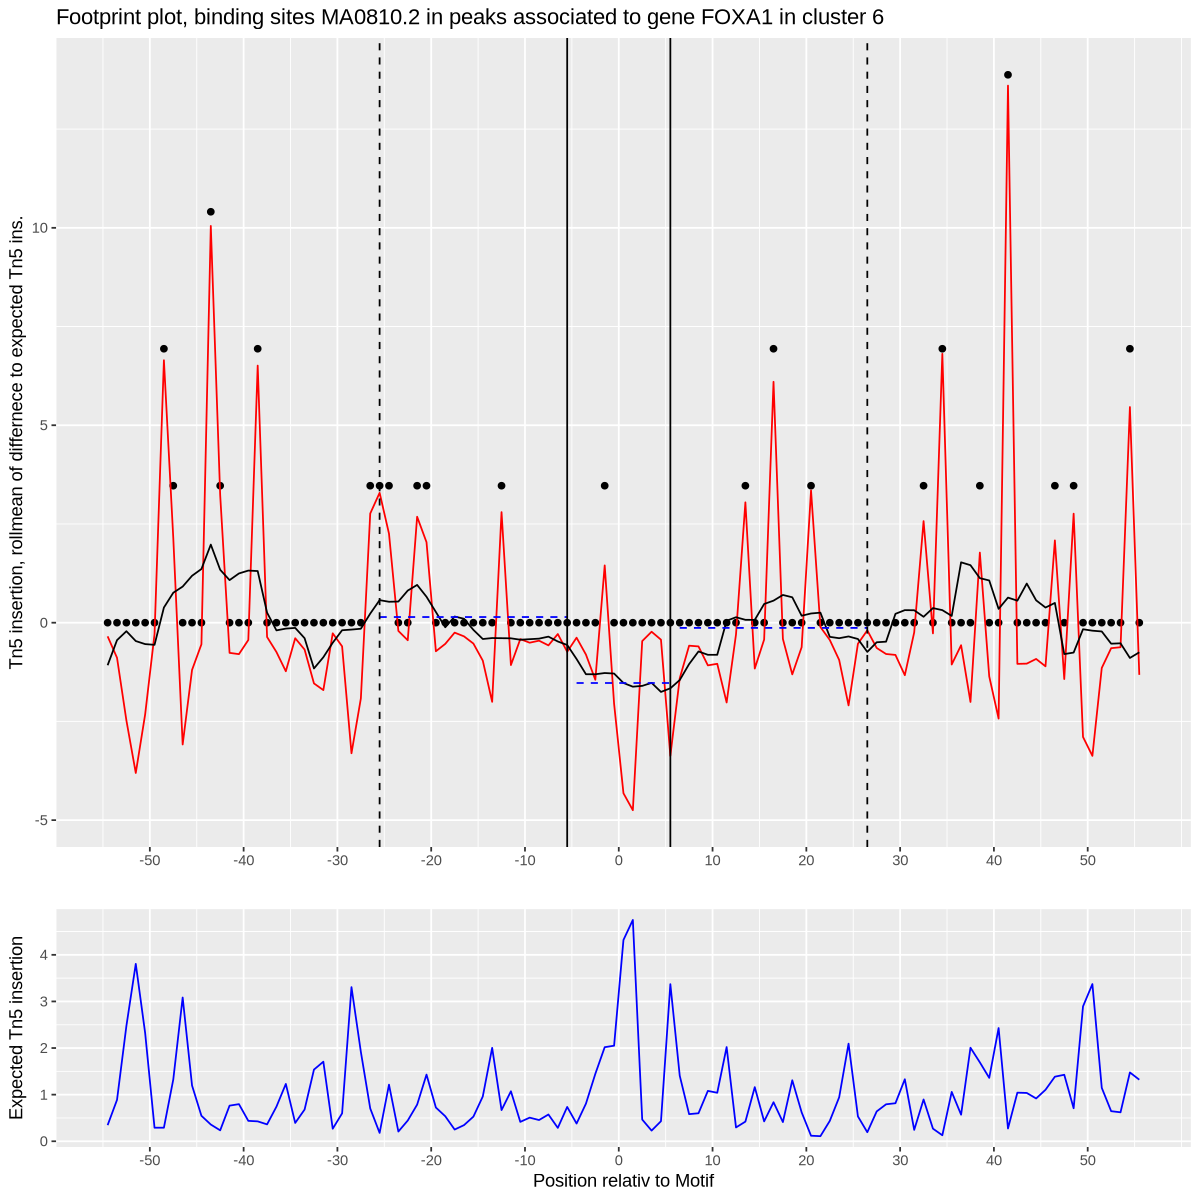

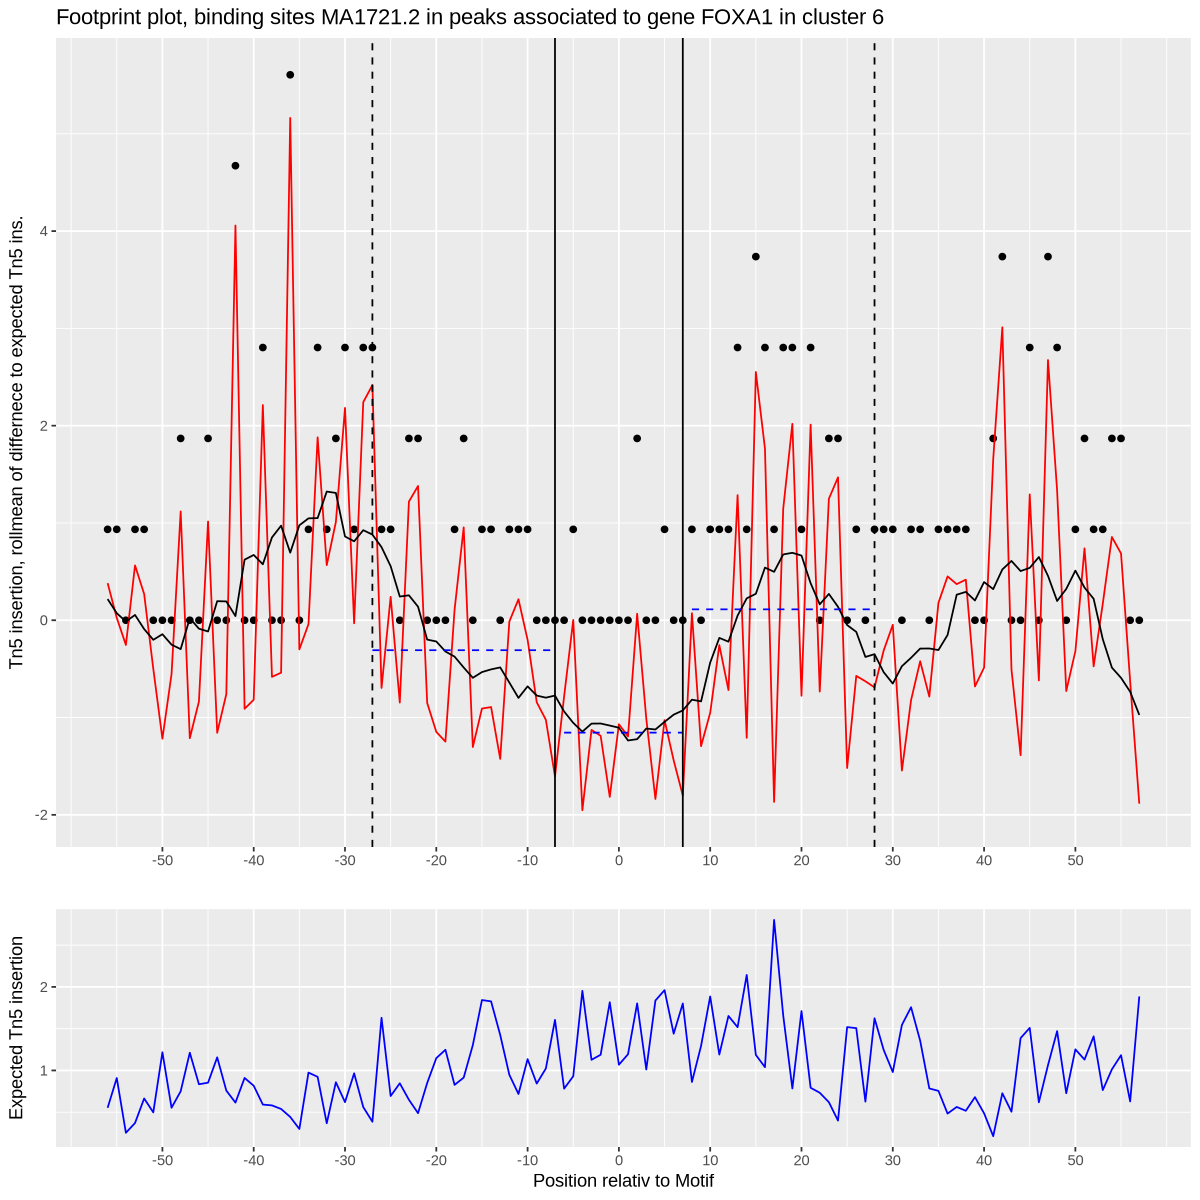

In [241]:

for(m in green_motifs){
    print(footprint_plots_by_TF(object=object_w_net, gene='FOXA1', cluster=6, motif_id=m, path=NULL))
}
